# 股指多日拟合 v7（公司行为调整）


## 环境与依赖

In [1]:
from __future__ import annotations

import json
import math
import os
import re
import sys
import time
import hashlib
import pickle
import warnings
from datetime import date, datetime, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import requests
from IPython.display import display

from xtquant import xtdatacenter as xtdc
from xtquant import xtdata
xtdata.reconnect(port = 58610)

PROJECT_ROOT = Path.cwd().resolve()

BASE_URL = "https://quantapi.51ifind.com/api/v1"

# ========== 指数配置：改 INDEX_CODE 即可切换 ==========
# INDEX_CODE = "000016"  # 上证50
INDEX_CODE = "000300"  # 沪深300
# INDEX_CODE = "000905"  # 中证500
# INDEX_CODE = "000852"  # 中证1000
# INDEX_CODE = "000688"  # 科创50

INDEX_META = {
    "000016": {"name": "上证50", "ths": "000016.SH", "futures": "IH00.CFE", "primary_etf": "510050.SH"},
    "000300": {"name": "沪深300", "ths": "000300.SH", "futures": "IF00.CFE", "primary_etf": "510300.SH"},
    "000905": {"name": "中证500", "ths": "000905.SH", "futures": "IC00.CFE", "primary_etf": "510500.SH"},
    "000852": {"name": "中证1000", "ths": "000852.SH", "futures": "IM00.CFE", "primary_etf": "512100.SH"},
    "000688": {"name": "科创50", "ths": "000688.SH", "futures": "IC00.CFE", "primary_etf": "588000.SH"},
}

EX_DIVIDEND_COLUMN_MAP = {
    "thscode": "股票代码",
    "time": "报告期_财报期末",
    "ths_ex_dividend_date_stock": "除权除息日",
    "ths_dividend_ps_before_tax_stock": "每股派息_税前",
    "ths_bonus_shares_ps_stock": "每股送股",
}

LIMIT_STATUS_COLUMN_MAP = {
    "thscode": "股票代码",
    "time": "状态日期",
    "ths_up_and_down_status_stock": "涨跌停状态",
    "is_limit_up": "前日是否涨停",
    "is_limit_down": "前日是否跌停",
    "is_suspended": "前日是否停牌",
    "can_trade_today_hint": "今日交易参考",
}

SSE_QUERY_URL = "https://query.sse.com.cn/commonQuery.do"
SSE_REFERER = "https://www.sse.com.cn/disclosure/fund/etflist/"
SSE_COMPONENT_SQL_ID = "COMMON_SSE_CP_JJLB_ETFJJGK_GGSGSHQD_COMPONENT_C"

INDEX_UNITS = 14
CONTRACT_MULTIPLIER = 300.0
PRICE_TOLERANCE = 0.0001

if INDEX_CODE not in INDEX_META:
    raise RuntimeError(f"ifind_import_helpers.INDEX_META 未配置指数 {INDEX_CODE}")
index_meta = INDEX_META[INDEX_CODE]
index_name = index_meta["name"]
print("项目目录:", PROJECT_ROOT)
print("参数:", INDEX_CODE, index_name, INDEX_UNITS, CONTRACT_MULTIPLIER)


***** xtdata连接成功 2026-07-07 09:40:53*****
服务信息: {'tag': 'qmt_research', 'version': '1.0'}
服务地址: 127.0.0.1:58610
数据路径: E:\迅投极速交易终端睿智融科版\datadir
设置xtdata.enable_hello = False可隐藏此消息

项目目录: E:\Codex\系统\Stock-Index-Fitting
参数: 000300 沪深300 14 300.0


In [2]:
from utils import (read_daily_data, read_csi_file, build_run_paths, read_stocks_ticks,
                   SseEtfPcfScraper, print_preview, resolve_sse50_etf_codes, save_outputs, download_csi_constituent_v02,
                   fetch_szse_pcf, calculate_exposure_deviation,
                   build_corporate_action_quantity_schedule, build_minute_tracking_analysis, combine_minute_tracking_results, save_tracking_outputs,)
from utils import gogoal_query

## 参数设置

In [3]:
# Trading rule file.
# security_buy_rules_special.csv: min quantity 1, step 1.
# security_buy_rules.csv: normal exchange-style rules.
# rule_file_path = "security_buy_rules_special.csv"
rule_file_path = "security_buy_rules.csv"

# baseline_date is used to read closes and build the initial basket.
# fitting_date_ls is used to read 1m ticks and evaluate the basket over one or more dates.
baseline_date_dash = "2026-06-26"
fitting_date_ls = ["20260629", "20260630", "20260701"]

# Whether stock dividends / transfer shares are reflected in basket valuation and charts.
# True: use actual holdings after ex-right adjustments.
# False: keep original target_qty for basket valuation; dividend records are still generated.
apply_corporate_actions_to_basket = True

# Real index minute price caliber used for the index line.
# Options: "preClose", "open", "close".
real_index_price_caliber = "close"

# Real index amount calculation mode.
# "basket_base_scaled": real_index_price / baseline_date_index_close * basket_base_amount.
# "contract_notional": real_index_price * INDEX_UNITS * CONTRACT_MULTIPLIER.
real_index_amount_mode = "basket_base_scaled"


## 重复使用的辅助函数

In [4]:
def to_xt_stock_code(code) -> str:
    text = str(code).strip()
    if "." in text:
        left, right = text.split(".", 1)
        return f"{left.zfill(6)}.{right.upper()}"

    code6 = text.zfill(6)
    if code6.startswith(("6", "9")):
        return f"{code6}.SH"
    if code6.startswith(("0", "2", "3")):
        return f"{code6}.SZ"
    if code6.startswith(("4", "8")):
        return f"{code6}.BJ"
    raise ValueError(f"无法识别证券代码市场: {code}")

def normalize_stock_code(value) -> str:
    raw = str(value).strip().upper()
    if raw.endswith((".SH", ".SZ", ".BJ")):
        return raw
    digits = raw.split(".")[0].zfill(6)
    return f"{digits}.SH" if digits.startswith(("5", "6", "9")) else f"{digits}.SZ"


def require_columns(frame: pd.DataFrame, columns: list[str], label: str) -> None:
    missing = [c for c in columns if c not in frame.columns]
    if missing:
        raise RuntimeError(f"{label} 缺少明确字段 {missing}；实际字段={frame.columns.tolist()}")


def save_csv(frame: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    frame.to_csv(path, index=False, encoding="utf-8-sig")
    print(f"已保存: {path} shape={frame.shape}")


def show_frame(label: str, frame: pd.DataFrame, rows: int = 5) -> None:
    print(f"{label}: shape={frame.shape}")
    print("字段:", frame.columns.tolist())
    display(frame.head(rows))


def floor_legal_quantity(quantity: float, minimum: int, step: int) -> int:
    if quantity < minimum:
        return 0
    return int(minimum + math.floor((quantity - minimum) / step) * step)


def sql_literal(value) -> str:
    return "'" + str(value).replace("'", "''") + "'"


def sql_in(values) -> str:
    vals = list(values)
    if not vals:
        raise ValueError("SQL IN 列表为空")
    return ", ".join(sql_literal(v) for v in vals)


def strip_market_suffix(value) -> str:
    return str(value).strip().upper().split(".")[0].zfill(6)


def normalize_trade_date(value) -> str:
    return pd.Timestamp(value).strftime("%Y%m%d")


def normalize_trade_date_dash(value) -> str:
    return pd.Timestamp(value).strftime("%Y-%m-%d")



def fetch_gogoal_index_close(index_code: str, trade_date: str) -> pd.DataFrame:
    sql = f"""
        SELECT trade_date, index_code, index_name, tclose, lclose, is_valid
        FROM qt_idx_daily
        WHERE index_code = {sql_literal(index_code)}
          AND trade_date = {sql_literal(normalize_trade_date_dash(trade_date))}
          AND is_valid = 1
    """
    return gogoal_query(sql, output_format="dataframe")


def fetch_gogoal_stock_closes(stock_codes: list[str], trade_date: str) -> pd.DataFrame:
    stripped_codes = [strip_market_suffix(code) for code in stock_codes]
    sql = f"""
        SELECT trade_date, stock_code, stock_name, tclose, lclose, is_valid
        FROM qt_stk_daily
        WHERE trade_date = {sql_literal(normalize_trade_date_dash(trade_date))}
          AND stock_code IN ({sql_in(stripped_codes)})
          AND is_valid = 1
    """
    raw = gogoal_query(sql, output_format="dataframe")
    if raw.empty:
        return pd.DataFrame(columns=["stock_code", "gogoal_close", "gogoal_lclose", "stock_name_gogoal"])
    raw["stock_code"] = raw["stock_code"].map(normalize_stock_code)
    return raw.rename(columns={
        "stock_name": "stock_name_gogoal",
        "tclose": "gogoal_close",
        "lclose": "gogoal_lclose",
    })[["stock_code", "stock_name_gogoal", "gogoal_close", "gogoal_lclose"]]


def fetch_gogoal_corporate_actions(stock_codes: list[str], start_date: str, end_date: str) -> pd.DataFrame:
    stripped_codes = [strip_market_suffix(code) for code in stock_codes]
    sql = f"""
        SELECT
            stock_code,
            stock_name,
            declare_date,
            xr_xd_date AS ex_date,
            beftax_maxcashdiv,
            beftax_mincashdiv,
            aftax_cashdiv,
            stockdiv_ratio,
            trans_ratio,
            bonus_ratio,
            is_newest,
            is_valid
        FROM bas_stk_hisdistribution
        WHERE stock_code IN ({sql_in(stripped_codes)})
          AND xr_xd_date >= {sql_literal(normalize_trade_date_dash(start_date))}
          AND xr_xd_date <= {sql_literal(normalize_trade_date_dash(end_date))}
          AND is_valid = 1
    """
    raw = gogoal_query(sql, output_format="dataframe")
    if raw.empty:
        return pd.DataFrame(columns=["stock_code", "ex_date"])
    raw["stock_code"] = raw["stock_code"].map(normalize_stock_code)
    raw["ex_date"] = pd.to_datetime(raw["ex_date"], errors="coerce").dt.strftime("%Y-%m-%d")
    return raw


## Task0：初始化运行环境

In [5]:
#Task0
if not re.fullmatch(r"\d{6}", INDEX_CODE):
    raise ValueError("INDEX_CODE 必须为六位数字字符串")
if not isinstance(INDEX_UNITS, int) or isinstance(INDEX_UNITS, bool) or INDEX_UNITS <= 0:
    raise ValueError("INDEX_UNITS 必须为正整数")
if not isinstance(CONTRACT_MULTIPLIER, (int, float)) or CONTRACT_MULTIPLIER <= 0:
    raise ValueError("CONTRACT_MULTIPLIER 必须为正数")

started_at = datetime.now().astimezone()
import_time = started_at.strftime("%Y%m%d-%H%M")
run_dir = PROJECT_ROOT / "data" / INDEX_CODE / import_time
directory_names = [
    "01_index", "02_etf", "03_corporate_actions", "04_market",
    "05_trading_status", "06_trading_rules", "reports", "logs",
]
dirs = {name: run_dir / name for name in directory_names}
for directory in dirs.values():
    directory.mkdir(parents=True, exist_ok=True)

paths = {
    "index_weights": dirs["01_index"] / "index_weights.csv",
    "index_cons": dirs["01_index"] / "index_cons.csv",
    "index_check": dirs["01_index"] / "index_constituents_check.csv",
    "related_etfs": dirs["02_etf"] / "related_etfs.csv",
    "sse_pcf": dirs["02_etf"] / "sse_etf_components.csv",
    "szse_pcf": dirs["02_etf"] / "szse_etf_components.csv",      
    "xt_pcf": dirs["02_etf"] / "xt_etf_components.csv",
    "etf_check": dirs["02_etf"] / "etf_cross_check.csv",
    "actions_gogoal": dirs["03_corporate_actions"] / "corporate_actions_gogoal.csv",
    "actions_xt": dirs["03_corporate_actions"] / "corporate_actions_xt.csv",
    "actions_check": dirs["03_corporate_actions"] / "corporate_actions_cross_check.csv",
    "actions_ifind": dirs["03_corporate_actions"] / "corporate_actions_ifind.csv",
    "actions_merged": dirs["03_corporate_actions"] / "corporate_actions_merged.csv",
    "market_snapshot": dirs["04_market"] / "market_snapshot.csv",
    "market_gogoal": dirs["04_market"] / "market_gogoal.csv",
    "trading_status": dirs["05_trading_status"] / "trading_status.csv",
    "security_rules": dirs["06_trading_rules"] / "security_rules.csv",
    "rule_candidates": dirs["06_trading_rules"] / "rule_parser_candidates.csv",
    "component_rules": dirs["06_trading_rules"] / "component_rules.csv",
    "theoretical": dirs["reports"] / "theoretical_portfolio.csv",
    "target": dirs["reports"] / "target_portfolio.csv",
    "deviation": dirs["reports"] / "deviation_report.csv",
    "portfolio_summary": dirs["reports"] / "portfolio_summary.csv",
    "industry_exposure": dirs["reports"] / "industry_exposure.csv",            
    "market_cap_exposure": dirs["reports"] / "market_cap_exposure.csv",        
    "stock_top_deviations": dirs["reports"] / "stock_top_deviations.csv",      
    "run_summary": dirs["reports"] / "run_summary.csv",
    "report_xlsx": dirs["reports"] / "report.xlsx",
}
print("import_time:", import_time)
print("run_dir:", run_dir)


import_time: 20260707-0953
run_dir: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260707-0953


## Task2：通过 **迅投** 交易日历确定构建日

In [6]:
#Task2
index_exchange = index_meta["ths"].split(".")[-1]
xt_index_code = index_meta["ths"]
ifind_index_code = index_meta["ths"]

baseline_date = baseline_date_dash.replace("-", "")

if not isinstance(fitting_date_ls, (list, tuple)) or not fitting_date_ls:
    raise ValueError("fitting_date_ls must be a non-empty list, e.g. ['20260616', '20260617']")

# Deduplicate while preserving user input order. The total result is concatenated by date order later.
fitting_date_ls = list(dict.fromkeys(str(item).replace("-", "") for item in fitting_date_ls))
if not re.fullmatch(r"\d{8}", baseline_date):
    raise ValueError(f"baseline_date has invalid format: {baseline_date}")
for fitting_date in fitting_date_ls:
    if not re.fullmatch(r"\d{8}", fitting_date):
        raise ValueError(f"fitting_date has invalid format: {fitting_date}")
    if not baseline_date < fitting_date:
        raise RuntimeError(f"Date order error: baseline={baseline_date}, fitting={fitting_date}")

fitting_date_dash_ls = [pd.Timestamp(item).strftime("%Y-%m-%d") for item in fitting_date_ls]
first_fitting_date = min(fitting_date_ls)
last_fitting_date = max(fitting_date_ls)
first_fitting_date_dash = pd.Timestamp(first_fitting_date).strftime("%Y-%m-%d")
last_fitting_date_dash = pd.Timestamp(last_fitting_date).strftime("%Y-%m-%d")

today_datetime = datetime.now()
today_ymd = today_datetime.strftime("%Y%m%d")
today_dash = today_datetime.strftime("%Y-%m-%d")

print("Today:", today_ymd)
print("Pricing date baseline_date:", baseline_date, baseline_date_dash)
print("Fitting dates fitting_date_ls:", fitting_date_ls)
print("Fitting date span:", first_fitting_date, "->", last_fitting_date)


Today: 20260707
Pricing date baseline_date: 20260626 2026-06-26
Fitting dates fitting_date_ls: ['20260629', '20260630', '20260701']
Fitting date span: 20260629 -> 20260701


## 获取分钟tick

In [7]:
df_real_index_by_date = {}
_index_minute_raw_by_date = {}

for fitting_date in fitting_date_ls:
    print(f"Downloading real index 1m tick: {xt_index_code} {fitting_date}")
    xtdata.download_history_data(
        stock_code=xt_index_code,
        period="1m",
        start_time=fitting_date,
        end_time=fitting_date,
    )

    raw = xtdata.get_market_data_ex(
        field_list=[],
        stock_list=[xt_index_code],
        period="1m",
        start_time=fitting_date,
        end_time=fitting_date,
        count=-1,
    )
    _index_minute_raw_by_date[fitting_date] = raw

    frame = raw.get(xt_index_code)
    if frame is None or frame.empty:
        raise RuntimeError(f"Empty XtQuant index minute data: {xt_index_code} {fitting_date}")
    frame = frame.copy()
    frame["time"] = pd.to_datetime(frame.index)
    frame.index = frame["time"]
    df_real_index_by_date[fitting_date] = frame

# Compatibility alias for older exploratory cells. v5 uses df_real_index_by_date officially.
df_real_index = df_real_index_by_date[first_fitting_date]


In [8]:
df_real_index_summary = pd.DataFrame([
    {
        "fitting_date": fitting_date,
        "rows": len(frame),
        "first_time": frame.index[0] if len(frame.index) else None,
        "last_time": frame.index[-1] if len(frame.index) else None,
        "columns": ",".join(map(str, frame.columns)),
    }
    for fitting_date, frame in df_real_index_by_date.items()
])
display(df_real_index_summary)
display(df_real_index_by_date[first_fitting_date].head())


,fitting_date,rows,first_time,last_time,columns
0,20260629,241,2026-06-29 09:30:00,2026-06-29 15:00:00,"time,open,high,low,close,volume,amount,settele..."
1,20260630,241,2026-06-30 09:30:00,2026-06-30 15:00:00,"time,open,high,low,close,volume,amount,settele..."
2,20260701,241,2026-07-01 09:30:00,2026-07-01 15:00:00,"time,open,high,low,close,volume,amount,settele..."


,time,open,high,low,close,volume,amount,settelementPrice,openInterest,preClose,suspendFlag
time,,,,,,,,,,,
2026-06-29 09:30:00,2026-06-29 09:30:00,4866.043,4866.043,4866.043,4866.043,2705699,8.718716e+09,0.0,0,4868.220,0
2026-06-29 09:31:00,2026-06-29 09:31:00,4869.534,4869.632,4857.391,4857.391,7785125,2.327623e+10,0.0,0,4866.044,0
2026-06-29 09:32:00,2026-06-29 09:32:00,4856.669,4856.985,4848.566,4849.247,7676154,2.235654e+10,0.0,0,4857.391,0
2026-06-29 09:33:00,2026-06-29 09:33:00,4848.356,4855.206,4848.356,4855.206,6364972,1.830926e+10,0.0,0,4849.246,0
2026-06-29 09:34:00,2026-06-29 09:34:00,4855.287,4855.287,4849.226,4849.226,4675531,1.457808e+10,0.0,0,4855.207,0


## Task2B 


In [9]:
# 查询 Go-Goal 申万二级行业分类
# 中信二级 950 申万二级 444
sql_sw_l2_industry = """
SELECT
    stock_code,
    stock_name,
    industry_code,
    industry_name
FROM qt_indus_constituents
WHERE is_valid = 1
  AND use_status = 1
  AND standard_code = '444'
  AND industry_level = 2
"""
def to_xt_code(stock_code: str) -> str:
    code = str(stock_code).zfill(6)
    if code.startswith(("6", "9")):
        return f"{code}.SH"
    if code.startswith(("0", "2", "3")):
        return f"{code}.SZ"
    if code.startswith(("4", "8")):
        return f"{code}.BJ"
    raise ValueError(f"无法识别股票市场: {code}")

df_sw_l2_industry = gogoal_query(sql_sw_l2_industry, output_format="dataframe")

if df_sw_l2_industry.empty:
    raise RuntimeError("Go-Goal 未查询到申万二级行业分类数据")

df_sw_l2_industry["stock_code"] = df_sw_l2_industry["stock_code"].astype(str).str.zfill(6)
df_sw_l2_industry["xt_stock_code"] = df_sw_l2_industry["stock_code"].map(to_xt_stock_code)

df_sw_l2_industry = df_sw_l2_industry[
    ["xt_stock_code", "stock_code", "stock_name", "industry_code", "industry_name"]
].drop_duplicates()

正在尝试first_config连接: 192.168.1.30:3306
成功使用first_config连接数据库


In [10]:
display(df_sw_l2_industry.sort_values("industry_code").reset_index(drop=True))
print("申万二级行业分类记录数:", len(df_sw_l2_industry))

,xt_stock_code,stock_code,stock_name,industry_code,industry_name
0,000592.SZ,000592,平潭发展,801011,林业
1,002679.SZ,002679,福建金森,801011,林业
2,000663.SZ,000663,永安林业,801011,林业Ⅱ
3,600265.SH,600265,ST景谷,801011,林业
4,000019.SZ,000019,深粮控股,801012,农产品加工
...,...,...,...,...,...
5524,000917.SZ,000917,电广传媒,801995,电视广播Ⅱ
5525,000156.SZ,000156,华数传媒,801995,电视广播Ⅱ
5526,920021.SH,920021,流金科技,801995,电视广播Ⅱ
5527,301262.SZ,301262,海看股份,801995,电视广播Ⅱ


申万二级行业分类记录数: 5529


## Task3：下载、读取并校验 CSI 权重与成分

In [11]:
# Task3
index_weights_path = Path(f"./data/weights_projection/{INDEX_CODE}-{baseline_date}.csv")
if index_weights_path.exists():
    print("读取本地已有权重文件")
    df = pd.read_csv(index_weights_path)
    df_index_weights = df[['stock_code', 'stock_name']]
    df_index_weights['raw_weight_pct'] = df['projected_weight_pct']
    df_index_weights['closeweight_data_date'] = baseline_date_dash
    closeweight_data_date = baseline_date_dash
    df_index_weights['import_time'] = import_time
    show_frame("standardized CSI weights", df_index_weights)
else:
    weight_file = download_csi_constituent_v02(INDEX_CODE, str(dirs["01_index"]), "closeweight")
    cons_file = download_csi_constituent_v02(INDEX_CODE, str(dirs["01_index"]), "cons")
    if not weight_file or not cons_file:
        raise RuntimeError("CSI closeweight or constituents file download failed")
    raw_weights = read_csi_file(weight_file)
    raw_cons = read_csi_file(cons_file)
    if raw_weights is None or raw_cons is None or raw_weights.empty or raw_cons.empty:
        raise RuntimeError("CSI closeweight or constituents file is empty or cannot be parsed")

    CSI_DATE_FIELD = raw_weights.columns[0]
    CSI_CONS_DATE_FIELD = raw_cons.columns[0]
    CSI_CODE_FIELD = "\u6210\u4efd\u5238\u4ee3\u7801Constituent Code"
    CSI_NAME_FIELD = "\u6210\u4efd\u5238\u540d\u79f0Constituent Name"
    CSI_WEIGHT_FIELD = "\u6743\u91cd(%)weight"
    require_columns(raw_weights, [CSI_DATE_FIELD, CSI_CODE_FIELD, CSI_NAME_FIELD, CSI_WEIGHT_FIELD], "CSI closeweight")
    require_columns(raw_cons, [CSI_CONS_DATE_FIELD, CSI_CODE_FIELD, CSI_NAME_FIELD], "CSI constituents")


    def extract_single_csi_data_date(frame: pd.DataFrame, label: str) -> str:
        date_col = frame.columns[0]
        parsed_dates = []
        for value in frame[date_col].dropna().unique():
            raw = str(value).strip()
            if re.fullmatch(r"\d{8}", raw):
                parsed = pd.to_datetime(raw, format="%Y%m%d", errors="coerce")
            else:
                parsed = pd.to_datetime(value, errors="coerce")
            if pd.notna(parsed):
                parsed_dates.append(pd.Timestamp(parsed).strftime("%Y-%m-%d"))
        unique_dates = sorted(set(parsed_dates))
        if len(unique_dates) != 1:
            raise RuntimeError(f"{label} first-column date is not unique: {unique_dates}")
        return unique_dates[0]

    closeweight_data_date = extract_single_csi_data_date(raw_weights, "CSI closeweight file")
    cons_data_date = extract_single_csi_data_date(raw_cons, "CSI constituents file")

    df_index_weights = pd.DataFrame({
        "stock_code": raw_weights[CSI_CODE_FIELD].map(normalize_stock_code),
        "stock_name": raw_weights[CSI_NAME_FIELD].astype(str).str.strip(),
        "raw_weight_pct": pd.to_numeric(raw_weights[CSI_WEIGHT_FIELD], errors="coerce"),
        "closeweight_data_date": closeweight_data_date,
        "import_time": import_time,
    })
    df_index_cons = pd.DataFrame({
        "stock_code": raw_cons[CSI_CODE_FIELD].map(normalize_stock_code),
        "stock_name": raw_cons[CSI_NAME_FIELD].astype(str).str.strip(),
        "cons_data_date": cons_data_date,
        "import_time": import_time,
    })
    weight_set, cons_set = set(df_index_weights.stock_code), set(df_index_cons.stock_code)
    if df_index_weights["raw_weight_pct"].isna().any() or (df_index_weights["raw_weight_pct"] < 0).any():
        raise RuntimeError("CSI closeweight contains null or negative weights")
    if df_index_weights.stock_code.duplicated().any() or df_index_cons.stock_code.duplicated().any():
        raise RuntimeError("CSI files contain duplicated constituent codes")

    df_index_check = pd.DataFrame([{
        "weight_count": len(weight_set),
        "cons_count": len(cons_set),
        "closeweight_data_date": closeweight_data_date,
        "cons_data_date": cons_data_date,
        "only_in_weights": "|".join(sorted(weight_set - cons_set)),
        "only_in_cons": "|".join(sorted(cons_set - weight_set)),
        "is_consistent": weight_set == cons_set,
        "closeweight_path": str(weight_file),
        "cons_path": str(cons_file),
        "import_time": import_time,
    }])
    save_csv(df_index_check, paths["index_check"])

    if weight_set != cons_set:
        display(df_index_check)
        raise RuntimeError("CSI closeweight and constituents code sets are inconsistent")

    save_csv(df_index_weights, paths["index_weights"])
    save_csv(df_index_cons, paths["index_cons"])
    stock_codes = df_index_weights["stock_code"].tolist()
    show_frame("standardized CSI weights", df_index_weights)
    show_frame("CSI closeweight/constituents check", df_index_check)
    print("CSI closeweight data date:", closeweight_data_date)
    print("CSI constituents data date:", cons_data_date)
    print("raw weight sum, not normalized:", df_index_weights["raw_weight_pct"].sum())


读取本地已有权重文件
standardized CSI weights: shape=(300, 5)
字段: ['stock_code', 'stock_name', 'raw_weight_pct', 'closeweight_data_date', 'import_time']


,stock_code,stock_name,raw_weight_pct,closeweight_data_date,import_time
0,300308.SZ,中际旭创,5.056006,2026-06-26,20260707-0953
1,300750.SZ,宁德时代,3.643286,2026-06-26,20260707-0953
2,300502.SZ,新易盛,2.853644,2026-06-26,20260707-0953
3,600519.SH,贵州茅台,2.641098,2026-06-26,20260707-0953
4,603986.SH,兆易创新,1.858881,2026-06-26,20260707-0953


## Task4：获取相关 ETF 并严格验证主 ETF PCF

In [12]:
# Task4 — ETF 申赎清单（SSE / SZSE 双源）
resolved_etf = index_meta.get("primary_etf", "")
if not resolved_etf:
    warnings.warn(f"指数 {INDEX_CODE} 未配置 primary_etf，跳过 Task4。")
    print("⏭️ Task4 跳过")
else:
    print(f"主 ETF: {resolved_etf}")

    if resolved_etf.endswith(".SH"):
        etf_code_digits = resolved_etf.split(".")[0]
        scraper = SseEtfPcfScraper()
        try:
            df_components, df_basic, _ = scraper.scrape_etfs([etf_code_digits], {})
            if df_components.empty:
                warnings.warn(f"SSE PCF 返回空: {resolved_etf}")
            else:
                df_pcf_out = df_components.rename(columns={
                    "证券代码": "stock_code",
                    "证券简称": "stock_name",
                    "股票数量_股": "component_qty",
                    "现金替代标志": "substitution_flag",
                })
                df_pcf_out["stock_code"] = df_pcf_out["stock_code"].map(normalize_stock_code)
                df_pcf_out["etf_code"] = resolved_etf
                df_pcf_out["source"] = "SSE"
                df_pcf_out["retrieved_at"] = datetime.now().isoformat()
                df_pcf_out["import_time"] = import_time
                out_cols = ["etf_code", "stock_code", "stock_name", "component_qty",
                           "substitution_flag", "source", "retrieved_at", "import_time"]
                df_pcf_out = df_pcf_out[[c for c in out_cols if c in df_pcf_out.columns]]
                save_csv(df_pcf_out, paths["sse_pcf"])
                show_frame("上交所主 ETF 申赎清单", df_pcf_out)
        except Exception as e:
            warnings.warn(f"SSE PCF 爬取失败（不阻断主流程）: {e}")

    elif resolved_etf.endswith(".SZ"):
        etf_code_digits = resolved_etf.split(".")[0]
        try:
            df_pcf_out = fetch_szse_pcf(etf_code_digits, first_fitting_date)
            df_pcf_out["stock_code"] = df_pcf_out["stock_code"].map(normalize_stock_code)
            df_pcf_out["import_time"] = import_time
            save_csv(df_pcf_out, paths["szse_pcf"])
            show_frame("深交所主 ETF 申赎清单", df_pcf_out)
        except Exception as e:
            warnings.warn(f"SZSE PCF 爬取失败（不阻断主流程）: {e}")
    else:
        warnings.warn(f"主 ETF 后缀无法识别: {resolved_etf}")


主 ETF: 510300.SH
已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260707-0953\02_etf\sse_etf_components.csv shape=(300, 8)
上交所主 ETF 申赎清单: shape=(300, 8)
字段: ['etf_code', 'stock_code', 'stock_name', 'component_qty', 'substitution_flag', 'source', 'retrieved_at', 'import_time']


,etf_code,stock_code,stock_name,component_qty,substitution_flag,source,retrieved_at,import_time
0,510300.SH,000001.SZ,平安银行,1500,允许,SSE,2026-07-07T09:53:43.467625,20260707-0953
1,510300.SH,000002.SZ,万科A,1100,允许,SSE,2026-07-07T09:53:43.467625,20260707-0953
2,510300.SH,000063.SZ,中兴通讯,500,允许,SSE,2026-07-07T09:53:43.467625,20260707-0953
3,510300.SH,000100.SZ,TCL科技,3300,允许,SSE,2026-07-07T09:53:43.467625,20260707-0953
4,510300.SH,000157.SZ,中联重科,800,允许,SSE,2026-07-07T09:53:43.467625,20260707-0953


In [ ]:
# Task4：从迅投获取 ETF 申赎清单，并与官网爬取结果校验

def to_xt_etf_code(code) -> str:
    text = str(code).strip()
    if "." in text:
        left, right = text.split(".", 1)
        return f"{left.zfill(6)}.{right.upper()}"

    code6 = text.zfill(6)
    if code6.startswith(("5", "6")):
        return f"{code6}.SH"
    if code6.startswith(("1", "15", "16", "18")):
        return f"{code6}.SZ"
    return to_xt_stock_code(code6)

sse_code_col = '证券代码'
sse_qty_col = '股票数量_股'

if "etf_code" not in df_components.columns:
    raise RuntimeError("官网 PCF 缺少 etf_code 字段，无法逐 ETF 与迅投校验")

df_sse_pcf_check = pd.DataFrame({
    "etf_code": df_components["etf_code"].map(to_xt_etf_code),
    "stock_code": df_components[sse_code_col].map(to_xt_stock_code),
    "component_qty_sse": pd.to_numeric(df_components[sse_qty_col], errors="coerce"),
})
df_sse_pcf_check = (
    df_sse_pcf_check
    .dropna(subset=["stock_code", "component_qty_sse"])
    .drop_duplicates(["etf_code", "stock_code"])
)

if df_sse_pcf_check.empty:
    raise RuntimeError("官网 PCF 整理后为空")


# 2. 获取迅投 PCF
xtdata.download_etf_info()
all_etf_info = xtdata.get_etf_info() or {}
if not all_etf_info:
    raise RuntimeError("迅投 get_etf_info 返回为空")

target_etf_codes = sorted(df_sse_pcf_check["etf_code"].dropna().unique())

xt_component_rows = []
missing_xt_etfs = []

for etf_code in target_etf_codes:
    xt_info = all_etf_info.get(etf_code)
    if xt_info is None:
        # 有些环境 key 可能只有 6 位代码
        xt_info = all_etf_info.get(etf_code.split(".")[0])

    if xt_info is None:
        missing_xt_etfs.append(etf_code)
        continue

    xt_components_raw = pd.DataFrame(xt_info.get("成份股信息"))

    if xt_components_raw.empty:
        missing_xt_etfs.append(etf_code)
        continue

    xt_code_col = "成份股代码"
    xt_qty_col = "成份股数量"

    part = pd.DataFrame({
        "etf_code": etf_code,
        "stock_code": xt_components_raw[xt_code_col].map(to_xt_stock_code),
        "component_qty_xt": pd.to_numeric(xt_components_raw[xt_qty_col], errors="coerce"),
    })
    xt_component_rows.append(part)

if missing_xt_etfs:
    raise RuntimeError(f"迅投未获取到这些 ETF 的 PCF: {missing_xt_etfs}")

df_xt_pcf = pd.concat(xt_component_rows, ignore_index=True)
df_xt_pcf = (
    df_xt_pcf
    .dropna(subset=["stock_code", "component_qty_xt"])
    .drop_duplicates(["etf_code", "stock_code"])
)

if df_xt_pcf.empty:
    raise RuntimeError("迅投 PCF 整理后为空")


# 3. 逐 ETF 校验官网与迅投 PCF
df_etf_check = df_sse_pcf_check.merge(
    df_xt_pcf,
    on=["etf_code", "stock_code"],
    how="outer",
    indicator=True,
)

df_etf_check["qty_diff"] = (
    df_etf_check["component_qty_sse"] - df_etf_check["component_qty_xt"]
)
df_etf_check["qty_equal"] = np.isclose(
    df_etf_check["component_qty_sse"],
    df_etf_check["component_qty_xt"],
    rtol=0,
    atol=0,
    equal_nan=False,
)
df_etf_check["is_consistent"] = df_etf_check["_merge"].eq("both") & df_etf_check["qty_equal"]
df_etf_check["import_time"] = import_time

if "paths" in globals():
    save_csv(df_xt_pcf, paths["xt_pcf"])
    save_csv(df_etf_check, paths["etf_check"])

display(df_etf_check)

if not df_etf_check["is_consistent"].all():
    display(df_etf_check.loc[~df_etf_check["is_consistent"]])
    raise RuntimeError("官网与迅投 ETF PCF 成分或数量不一致")

print("ETF PCF 官网/迅投校验通过")
print("ETF 数量:", df_etf_check["etf_code"].nunique())
print("成分记录数:", len(df_etf_check))

已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260707-0953\02_etf\xt_etf_components.csv shape=(300, 3)
已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260707-0953\02_etf\etf_cross_check.csv shape=(300, 9)


,etf_code,stock_code,component_qty_sse,component_qty_xt,_merge,qty_diff,qty_equal,is_consistent,import_time
0,510300.SH,000001.SZ,1500,1500,both,0,True,True,20260707-0953
1,510300.SH,000002.SZ,1100,1100,both,0,True,True,20260707-0953
2,510300.SH,000063.SZ,500,500,both,0,True,True,20260707-0953
3,510300.SH,000100.SZ,3300,3300,both,0,True,True,20260707-0953
4,510300.SH,000157.SZ,800,800,both,0,True,True,20260707-0953
...,...,...,...,...,...,...,...,...,...
295,510300.SH,688396.SH,200,200,both,0,True,True,20260707-0953
296,510300.SH,688472.SH,200,200,both,0,True,True,20260707-0953
297,510300.SH,688506.SH,0,0,both,0,True,True,20260707-0953
298,510300.SH,688521.SH,200,200,both,0,True,True,20260707-0953


ETF PCF 官网/迅投校验通过
ETF 数量: 1
成分记录数: 300


## Task5：获取并合并公司行为

In [15]:
#Task5
stock_codes = df_index_weights["stock_code"].tolist()
# Corporate actions must be collected from the day after baseline_date, not only displayed fitting dates.
corporate_action_start_date = (pd.Timestamp(baseline_date) + timedelta(days=1)).strftime("%Y%m%d")
corporate_action_start_date_dash = pd.Timestamp(corporate_action_start_date).strftime("%Y-%m-%d")
future_date = (pd.Timestamp(last_fitting_date) + timedelta(days=1)).strftime("%Y%m%d")

df_actions_gogoal = fetch_gogoal_corporate_actions(stock_codes, corporate_action_start_date, last_fitting_date)
df_actions_gogoal["import_time"] = import_time

xt_action_frames = []
for stock_code in stock_codes:
    frame = xtdata.get_divid_factors(stock_code, corporate_action_start_date, last_fitting_date)
    if frame is not None and not frame.empty:
        item = frame.copy().reset_index().rename(columns={"index": "ex_date"})
        item.insert(0, "stock_code", stock_code)
        xt_action_frames.append(item)
df_actions_xt = pd.concat(xt_action_frames, ignore_index=True) if xt_action_frames else pd.DataFrame(columns=["stock_code", "ex_date"])
if not df_actions_xt.empty:
    df_actions_xt["stock_code"] = df_actions_xt["stock_code"].map(normalize_stock_code)
    df_actions_xt["ex_date"] = pd.to_datetime(df_actions_xt["ex_date"], errors="coerce").dt.strftime("%Y-%m-%d")
df_actions_xt["import_time"] = import_time

left_keys = df_actions_gogoal[["stock_code", "ex_date"]].drop_duplicates()
right_keys = df_actions_xt[["stock_code", "ex_date"]].drop_duplicates()
df_actions_check = left_keys.merge(right_keys, on=["stock_code", "ex_date"], how="outer", indicator=True)
df_actions_check["is_consistent"] = df_actions_check["_merge"].eq("both")
df_actions_check["import_time"] = import_time
if df_actions_gogoal.empty and df_actions_xt.empty:
    df_actions_check = pd.DataFrame([{
        "stock_code": None,
        "ex_date": None,
        "_merge": "both",
        "is_consistent": True,
        "note": "Go-Goal 与迅投在查询窗口内均无公司行为事件",
        "import_time": import_time,
    }])

df_actions_merged = df_actions_gogoal.merge(
    df_actions_xt, on=["stock_code", "ex_date"], how="outer", suffixes=("_gogoal", "_xt")
)
df_actions_merged["import_time"] = import_time

save_csv(df_actions_gogoal, paths["actions_gogoal"])
save_csv(df_actions_xt, paths["actions_xt"])
save_csv(df_actions_check, paths["actions_check"])
save_csv(df_actions_merged, paths["actions_merged"])
if not df_actions_check["is_consistent"].all():
    display(df_actions_check.loc[~df_actions_check["is_consistent"]])
    raise RuntimeError("Go-Goal 与迅投公司行为事件日期集合不一致")
show_frame("Go-Goal 公司行为主表", df_actions_xt)
show_frame("\u0047\u006f\u002d\u0047\u006f\u0061\u006c \u4e0e\u8fc5\u6295\u516c\u53f8\u884c\u4e3a\u6821\u9a8c", df_actions_check)


正在尝试first_config连接: 192.168.1.30:3306
成功使用first_config连接数据库


已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260706-0958\03_corporate_actions\corporate_actions_gogoal.csv shape=(12, 13)
已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260706-0958\03_corporate_actions\corporate_actions_xt.csv shape=(12, 11)
已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260706-0958\03_corporate_actions\corporate_actions_cross_check.csv shape=(12, 5)
已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260706-0958\03_corporate_actions\corporate_actions_merged.csv shape=(12, 23)
Go-Goal 公司行为主表: shape=(12, 11)
字段: ['stock_code', 'ex_date', 'time', 'interest', 'stockBonus', 'stockGift', 'allotNum', 'allotPrice', 'gugai', 'dr', 'import_time']


,stock_code,ex_date,time,interest,stockBonus,stockGift,allotNum,allotPrice,gugai,dr,import_time
0,000333.SZ,2026-06-29,1.782662e+12,3.800000,0.0,0.0,0.0,0.0,0.0,1.052269,20260706-0958
1,600406.SH,2026-06-30,1.782749e+12,0.475000,0.0,0.0,0.0,0.0,0.0,1.021104,20260706-0958
2,002049.SZ,2026-06-30,1.782749e+12,0.309999,0.0,0.0,0.0,0.0,0.0,1.003705,20260706-0958
3,002625.SZ,2026-06-30,1.782749e+12,0.035000,0.0,0.0,0.0,0.0,0.0,1.001001,20260706-0958
4,601825.SH,2026-06-29,1.782662e+12,0.194000,0.0,0.0,0.0,0.0,0.0,1.024050,20260706-0958


Go-Goal 与迅投公司行为校验: shape=(12, 5)
字段: ['stock_code', 'ex_date', '_merge', 'is_consistent', 'import_time']


,stock_code,ex_date,_merge,is_consistent,import_time
0,000333.SZ,2026-06-29,both,True,20260706-0958
1,002049.SZ,2026-06-30,both,True,20260706-0958
2,002304.SZ,2026-06-30,both,True,20260706-0958
3,002625.SZ,2026-06-30,both,True,20260706-0958
4,300450.SZ,2026-06-30,both,True,20260706-0958


## Task7：抓取官方规则并人工确认显式规则表

In [17]:
#Task7
# manual_rule_path = PROJECT_ROOT / "dataloader" / "security_buy_rules.csv"
manual_rule_path = PROJECT_ROOT / "dataloader" / rule_file_path

if not manual_rule_path.is_file():
    raise FileNotFoundError(f"人工交易规则文件不存在: {manual_rule_path}")

df_security_rules = pd.read_csv(
    manual_rule_path,
    dtype={
        "exchange": "string",
        "board": "string",
    },
)

required_rule_columns = [
    "exchange",
    "board",
    "buy_min_qty",
    "buy_qty_step",
]
require_columns(df_security_rules, required_rule_columns, "人工交易规则")

df_security_rules = df_security_rules[required_rule_columns].copy()
df_security_rules["exchange"] = df_security_rules["exchange"].str.strip().str.upper()
df_security_rules["board"] = df_security_rules["board"].str.strip().str.upper()

for column in ["buy_min_qty", "buy_qty_step"]:
    df_security_rules[column] = pd.to_numeric(
        df_security_rules[column],
        errors="raise",
    ).astype(int)

if df_security_rules[required_rule_columns].isna().any().any():
    raise RuntimeError("人工交易规则存在空值")

if df_security_rules.duplicated(["exchange", "board"]).any():
    raise RuntimeError("人工交易规则存在重复的交易所与板块组合")

if (df_security_rules[["buy_min_qty", "buy_qty_step"]] <= 0).any().any():
    raise RuntimeError("人工交易规则中的数量必须为正整数")

expected_rule_keys = {
    ("SH", "MAIN"),
    ("SH", "STAR"),
    ("SZ", "MAIN"),
    ("SZ", "CHINEXT"),
    ("BJ", "MAIN"),
}
actual_rule_keys = set(
    df_security_rules[["exchange", "board"]].itertuples(index=False, name=None)
)

if actual_rule_keys != expected_rule_keys:
    raise RuntimeError(
        f"人工交易规则板块不完整或包含未知板块: "
        f"missing={expected_rule_keys - actual_rule_keys}, "
        f"unexpected={actual_rule_keys - expected_rule_keys}"
    )

df_security_rules["import_time"] = import_time

# 保存本次运行实际采用的规则快照，供 Task8 继续使用。
save_csv(df_security_rules, paths["security_rules"])
show_frame("人工维护的交易规则", df_security_rules)


已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260706-0958\06_trading_rules\security_rules.csv shape=(5, 5)
人工维护的交易规则: shape=(5, 5)
字段: ['exchange', 'board', 'buy_min_qty', 'buy_qty_step', 'import_time']


,exchange,board,buy_min_qty,buy_qty_step,import_time
0,SH,MAIN,100,100,20260706-0958
1,SH,STAR,200,1,20260706-0958
2,SZ,MAIN,100,100,20260706-0958
3,SZ,CHINEXT,100,100,20260706-0958
4,BJ,MAIN,100,1,20260706-0958


## Task8：识别板块并匹配交易规则

In [18]:
#Task8
df_component_rules = df_index_weights.copy()
df_component_rules["exchange"] = df_component_rules["stock_code"].str[-2:]
df_component_rules["board"] = "MAIN"
df_component_rules.loc[df_component_rules["stock_code"].str.startswith("68"), "board"] = "STAR"
df_component_rules.loc[df_component_rules["stock_code"].str.startswith("30"), "board"] = "CHINEXT"
df_component_rules.loc[df_component_rules["stock_code"].str.startswith("920"), "exchange"] = "BJ"
df_component_rules.loc[df_component_rules["exchange"] == "BJ", "board"] = "MAIN"
if (~df_component_rules["exchange"].isin(["SH", "SZ"])).any():
    raise RuntimeError("第一版出现不支持的交易所")
df_component_rules = df_component_rules.merge(
    df_security_rules.drop(columns=["import_time"]), on=["exchange", "board"], how="left", validate="many_to_one"
)
if df_component_rules[["buy_min_qty", "buy_qty_step"]].isna().any(axis=None):
    display(df_component_rules.loc[df_component_rules[["buy_min_qty", "buy_qty_step"]].isna().any(axis=1)])
    raise RuntimeError("存在无法唯一匹配交易数量规则的成分股")
df_component_rules["import_time"] = import_time
save_csv(df_component_rules, paths["component_rules"])
show_frame("成分股板块与交易规则", df_component_rules)


已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260706-0958\06_trading_rules\component_rules.csv shape=(300, 9)
成分股板块与交易规则: shape=(300, 9)
字段: ['stock_code', 'stock_name', 'raw_weight_pct', 'closeweight_data_date', 'import_time', 'exchange', 'board', 'buy_min_qty', 'buy_qty_step']


,stock_code,stock_name,raw_weight_pct,closeweight_data_date,import_time,exchange,board,buy_min_qty,buy_qty_step
0,300308.SZ,中际旭创,5.056006,2026-06-26,20260706-0958,SZ,CHINEXT,100,100
1,300750.SZ,宁德时代,3.643286,2026-06-26,20260706-0958,SZ,CHINEXT,100,100
2,300502.SZ,新易盛,2.853644,2026-06-26,20260706-0958,SZ,CHINEXT,100,100
3,600519.SH,贵州茅台,2.641098,2026-06-26,20260706-0958,SH,MAIN,100,100
4,603986.SH,兆易创新,1.858881,2026-06-26,20260706-0958,SH,MAIN,100,100


## Task9：获取并交叉验证构建日行情

In [19]:
#Task9
# v5: build the target basket from baseline_date closes; fitting_date_ls is only for later 1m tick tracking.
pricing_date = baseline_date
pricing_date_dash = baseline_date_dash
stock_codes = df_index_weights["stock_code"].tolist()

# Index close: Go-Goal is primary, XtQuant daily data is used as validation.
df_gogoal_index = fetch_gogoal_index_close(INDEX_CODE, pricing_date)
if df_gogoal_index.empty:
    raise RuntimeError(f"Empty Go-Goal index daily data: {INDEX_CODE} {pricing_date}")
require_columns(df_gogoal_index, ["tclose"], "Go-Goal index daily data")
index_close_gogoal = float(pd.to_numeric(df_gogoal_index["tclose"], errors="coerce").dropna().iloc[-1])

xtdata.download_history_data(xt_index_code, period="1d", start_time=pricing_date, end_time=pricing_date)
xt_index_data = xtdata.get_market_data_ex(
    field_list=[], stock_list=[xt_index_code], period="1d",
    start_time=pricing_date, end_time=pricing_date, count=-1,
    dividend_type="none", fill_data=False,
)
xt_index_frame = xt_index_data.get(xt_index_code)
if xt_index_frame is None or xt_index_frame.empty:
    raise RuntimeError("Empty XtQuant index daily data")
require_columns(xt_index_frame, ["close"], "XtQuant index daily data")
index_close_xt = float(pd.to_numeric(xt_index_frame["close"], errors="coerce").dropna().iloc[-1])
index_relative_deviation = abs(index_close_gogoal - index_close_xt) / abs(index_close_gogoal)
if not np.isfinite(index_close_gogoal) or index_close_gogoal <= 0 or index_relative_deviation > PRICE_TOLERANCE:
    raise RuntimeError(
        f"Index close validation failed: gogoal={index_close_gogoal}, xt={index_close_xt}, deviation={index_relative_deviation}"
    )
index_close = index_close_gogoal

# Constituent closes: Go-Goal is primary, NAS daily data is used as validation. Always use pricing_date here.
df_gogoal_close = fetch_gogoal_stock_closes(stock_codes, pricing_date)
if df_gogoal_close.empty:
    raise RuntimeError("Empty Go-Goal constituent daily data")
df_gogoal_close["gogoal_close"] = pd.to_numeric(df_gogoal_close["gogoal_close"], errors="coerce")
df_gogoal_close["gogoal_lclose"] = pd.to_numeric(df_gogoal_close["gogoal_lclose"], errors="coerce")

nas_daily = read_daily_data(pricing_date)
if nas_daily is None or nas_daily.empty:
    raise RuntimeError("Empty NAS daily data")
require_columns(nas_daily, ["xt_stock_code", "tclose"], "NAS daily data")
df_nas_close = nas_daily.loc[nas_daily["xt_stock_code"].isin(stock_codes), ["xt_stock_code", "tclose"]].copy()
df_nas_close.columns = ["stock_code", "nas_close"]
df_nas_close["nas_close"] = pd.to_numeric(df_nas_close["nas_close"], errors="coerce")

df_market_snapshot = pd.DataFrame({"stock_code": stock_codes}).merge(
    df_gogoal_close, on="stock_code", how="left"
).merge(
    df_nas_close, on="stock_code", how="left"
)
df_market_snapshot["relative_deviation"] = (
    (df_market_snapshot["gogoal_close"] - df_market_snapshot["nas_close"]).abs()
    / df_market_snapshot["gogoal_close"].abs()
)
df_market_snapshot["close_price"] = df_market_snapshot["gogoal_close"]
df_market_snapshot["pricing_date"] = pricing_date
df_market_snapshot["fitting_dates"] = ",".join(fitting_date_ls)
df_market_snapshot["import_time"] = import_time

save_csv(df_gogoal_close, paths["market_gogoal"])
save_csv(df_market_snapshot, paths["market_snapshot"])
invalid_market = (
    df_market_snapshot[["gogoal_close", "nas_close"]].isna().any(axis=1)
    | (df_market_snapshot[["gogoal_close", "nas_close"]] <= 0).any(axis=1)
    | (df_market_snapshot["relative_deviation"] > PRICE_TOLERANCE)
)
if invalid_market.any():
    display(df_market_snapshot.loc[invalid_market])
    raise RuntimeError("Pricing-date constituent close validation failed")
show_frame("Pricing-date market snapshot", df_market_snapshot)
print("Pricing date:", pricing_date)
print("Fitting dates:", fitting_date_ls)
print("Go-Goal index close for pricing:", index_close)


正在尝试first_config连接: 192.168.1.30:3306
成功使用first_config连接数据库
正在尝试first_config连接: 192.168.1.30:3306
成功使用first_config连接数据库


成功读取日行情数据
  文件路径: Z:\高频行情迅投\日行情\2026\06\A_DAYBAR_20260626.pkl
  数据形状: (5528, 28)
已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260706-0958\04_market\market_gogoal.csv shape=(300, 4)
已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260706-0958\04_market\market_snapshot.csv shape=(300, 10)
Pricing-date market snapshot: shape=(300, 10)
字段: ['stock_code', 'stock_name_gogoal', 'gogoal_close', 'gogoal_lclose', 'nas_close', 'relative_deviation', 'close_price', 'pricing_date', 'fitting_dates', 'import_time']


,stock_code,stock_name_gogoal,gogoal_close,gogoal_lclose,nas_close,relative_deviation,close_price,pricing_date,fitting_dates,import_time
0,300308.SZ,中际旭创,1253.89,1323.40,1253.89,0.0,1253.89,20260626,"20260629,20260630,20260701",20260706-0958
1,300750.SZ,宁德时代,381.00,401.90,381.00,0.0,381.00,20260626,"20260629,20260630,20260701",20260706-0958
2,300502.SZ,新易盛,566.00,610.49,566.00,0.0,566.00,20260626,"20260629,20260630,20260701",20260706-0958
3,600519.SH,贵州茅台,1168.63,1184.08,1168.63,0.0,1168.63,20260626,"20260629,20260630,20260701",20260706-0958
4,603986.SH,兆易创新,770.00,775.21,770.00,0.0,770.00,20260626,"20260629,20260630,20260701",20260706-0958


Pricing date: 20260626
Fitting dates: ['20260629', '20260630', '20260701']
Go-Goal index close for pricing: 4868.2205


## Task10：拟合前完整性校验关卡

In [20]:
#Task10
sets = [
    set(df_index_weights["stock_code"]),
    set(df_component_rules["stock_code"]),
    set(df_market_snapshot["stock_code"]),
]
if not sets[0] == sets[1] == sets[2]:
    raise RuntimeError("拟合输入成分集合不一致")
for label, frame in [
    ("指数权重", df_index_weights), ("成分规则", df_component_rules), ("行情快照", df_market_snapshot)
]:
    if frame["stock_code"].duplicated().any():
        raise RuntimeError(f"{label} 包含重复股票")
if df_index_weights["raw_weight_pct"].isna().any() or (df_index_weights["raw_weight_pct"] < 0).any():
    raise RuntimeError("指数权重无效")
if df_market_snapshot["close_price"].isna().any() or (df_market_snapshot["close_price"] <= 0).any():
    raise RuntimeError("构建日权威收盘价无效")
print("Task10 完整性校验通过，股票数量:", len(sets[0]))


Task10 完整性校验通过，股票数量: 300


## Task11：计算理论股票篮子

In [21]:
#Task11
target_stock_value = index_close * CONTRACT_MULTIPLIER * INDEX_UNITS
df_theoretical_portfolio = df_component_rules[[
    "stock_code", "stock_name", "raw_weight_pct", "exchange", "board", "buy_min_qty", "buy_qty_step"
]].merge(df_market_snapshot[["stock_code", "close_price"]], on="stock_code", validate="one_to_one")
df_theoretical_portfolio["raw_weight"] = df_theoretical_portfolio["raw_weight_pct"] / 100.0
df_theoretical_portfolio["target_stock_value"] = target_stock_value
df_theoretical_portfolio["theoretical_amount"] = target_stock_value * df_theoretical_portfolio["raw_weight"]
df_theoretical_portfolio["theoretical_qty"] = (
    df_theoretical_portfolio["theoretical_amount"] / df_theoretical_portfolio["close_price"]
)
df_theoretical_portfolio["pricing_date"] = pricing_date
df_theoretical_portfolio["fitting_dates"] = ",".join(fitting_date_ls)
df_theoretical_portfolio["import_time"] = import_time
save_csv(df_theoretical_portfolio, paths["theoretical"])
show_frame("Theoretical stock basket", df_theoretical_portfolio)
print("Target stock amount:", target_stock_value)


已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260706-0958\reports\theoretical_portfolio.csv shape=(300, 15)
Theoretical stock basket: shape=(300, 15)
字段: ['stock_code', 'stock_name', 'raw_weight_pct', 'exchange', 'board', 'buy_min_qty', 'buy_qty_step', 'close_price', 'raw_weight', 'target_stock_value', 'theoretical_amount', 'theoretical_qty', 'pricing_date', 'fitting_dates', 'import_time']


,stock_code,stock_name,raw_weight_pct,exchange,board,buy_min_qty,buy_qty_step,close_price,raw_weight,target_stock_value,theoretical_amount,theoretical_qty,pricing_date,fitting_dates,import_time
0,300308.SZ,中际旭创,5.056006,SZ,CHINEXT,100,100,1253.89,0.050560,20446526.1,1.033778e+06,824.456321,20260626,"20260629,20260630,20260701",20260706-0958
1,300750.SZ,宁德时代,3.643286,SZ,CHINEXT,100,100,381.00,0.036433,20446526.1,7.449254e+05,1955.184673,20260626,"20260629,20260630,20260701",20260706-0958
2,300502.SZ,新易盛,2.853644,SZ,CHINEXT,100,100,566.00,0.028536,20446526.1,5.834711e+05,1030.867582,20260626,"20260629,20260630,20260701",20260706-0958
3,600519.SH,贵州茅台,2.641098,SH,MAIN,100,100,1168.63,0.026411,20446526.1,5.400129e+05,462.090528,20260626,"20260629,20260630,20260701",20260706-0958
4,603986.SH,兆易创新,1.858881,SH,MAIN,100,100,770.00,0.018589,20446526.1,3.800765e+05,493.605902,20260626,"20260629,20260630,20260701",20260706-0958


Target stock amount: 20446526.1


## Task12：使用两步贪心法生成目标股票篮子

In [22]:
#Task12
df_target_portfolio = df_theoretical_portfolio.copy()
df_target_portfolio["initial_floor_qty"] = [
    floor_legal_quantity(qty, int(minimum), int(step))
    for qty, minimum, step in zip(
        df_target_portfolio["theoretical_qty"],
        df_target_portfolio["buy_min_qty"],
        df_target_portfolio["buy_qty_step"],
    )
]
df_target_portfolio["greedy_added_qty"] = 0
invested = float((df_target_portfolio["initial_floor_qty"] * df_target_portfolio["close_price"]).sum())

while invested > target_stock_value + 1e-8:
    reductions = []
    for idx, row in df_target_portfolio.loc[df_target_portfolio["initial_floor_qty"] > 0].iterrows():
        before_qty = int(row["initial_floor_qty"])
        remove_qty = int(row["buy_min_qty"] if before_qty == row["buy_min_qty"] else row["buy_qty_step"])
        after_qty = before_qty - remove_qty
        before_error = abs(before_qty * row["close_price"] - row["theoretical_amount"])
        after_error = abs(after_qty * row["close_price"] - row["theoretical_amount"])
        reductions.append((after_error - before_error, row["stock_code"], idx, remove_qty))
    if not reductions:
        raise RuntimeError("无法在合法数量约束下满足预算上限")
    _, _, idx, remove_qty = sorted(reductions, key=lambda item: (item[0], item[1]))[0]
    invested -= remove_qty * float(df_target_portfolio.at[idx, "close_price"])
    df_target_portfolio.at[idx, "initial_floor_qty"] -= remove_qty

greedy_steps = []
while True:
    candidates = []
    for idx, row in df_target_portfolio.iterrows():
        before_qty = int(row["initial_floor_qty"] + row["greedy_added_qty"])
        add_qty = int(row["buy_min_qty"] if before_qty == 0 else row["buy_qty_step"])
        cost = add_qty * float(row["close_price"])
        if invested + cost > target_stock_value + 1e-8:
            continue
        before_error = abs(before_qty * row["close_price"] - row["theoretical_amount"])
        after_error = abs((before_qty + add_qty) * row["close_price"] - row["theoretical_amount"])
        improvement = before_error - after_error
        if improvement > 1e-8:
            candidates.append((improvement, row["stock_code"], idx, add_qty, cost))
    if not candidates:
        break
    improvement, stock_code, idx, add_qty, cost = sorted(candidates, key=lambda item: (-item[0], item[1]))[0]
    df_target_portfolio.at[idx, "greedy_added_qty"] += add_qty
    invested += cost
    greedy_steps.append({"step_no": len(greedy_steps) + 1, "stock_code": stock_code, "added_qty": add_qty, "improvement": improvement})

df_target_portfolio["target_qty"] = df_target_portfolio["initial_floor_qty"] + df_target_portfolio["greedy_added_qty"]
df_target_portfolio["target_market_value"] = df_target_portfolio["target_qty"] * df_target_portfolio["close_price"]
df_target_portfolio["is_held"] = df_target_portfolio["target_qty"] > 0
if df_target_portfolio["target_market_value"].sum() > target_stock_value + 1e-8:
    raise RuntimeError("目标股票篮子超过预算")
for row in df_target_portfolio.itertuples():
    if row.target_qty != 0 and (row.target_qty < row.buy_min_qty or (row.target_qty - row.buy_min_qty) % row.buy_qty_step != 0):
        raise RuntimeError(f"目标数量不合法: {row.stock_code} {row.target_qty}")
save_csv(df_target_portfolio, paths["target"])
show_frame("目标股票篮子", df_target_portfolio)
display(pd.DataFrame(greedy_steps).head(20))


已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260706-0958\reports\target_portfolio.csv shape=(300, 20)
目标股票篮子: shape=(300, 20)
字段: ['stock_code', 'stock_name', 'raw_weight_pct', 'exchange', 'board', 'buy_min_qty', 'buy_qty_step', 'close_price', 'raw_weight', 'target_stock_value', 'theoretical_amount', 'theoretical_qty', 'pricing_date', 'fitting_dates', 'import_time', 'initial_floor_qty', 'greedy_added_qty', 'target_qty', 'target_market_value', 'is_held']


,stock_code,stock_name,raw_weight_pct,exchange,board,buy_min_qty,buy_qty_step,close_price,raw_weight,target_stock_value,theoretical_amount,theoretical_qty,pricing_date,fitting_dates,import_time,initial_floor_qty,greedy_added_qty,target_qty,target_market_value,is_held
0,300308.SZ,中际旭创,5.056006,SZ,CHINEXT,100,100,1253.89,0.050560,20446526.1,1.033778e+06,824.456321,20260626,"20260629,20260630,20260701",20260706-0958,800,0,800,1003112.0,True
1,300750.SZ,宁德时代,3.643286,SZ,CHINEXT,100,100,381.00,0.036433,20446526.1,7.449254e+05,1955.184673,20260626,"20260629,20260630,20260701",20260706-0958,1900,100,2000,762000.0,True
2,300502.SZ,新易盛,2.853644,SZ,CHINEXT,100,100,566.00,0.028536,20446526.1,5.834711e+05,1030.867582,20260626,"20260629,20260630,20260701",20260706-0958,1000,0,1000,566000.0,True
3,600519.SH,贵州茅台,2.641098,SH,MAIN,100,100,1168.63,0.026411,20446526.1,5.400129e+05,462.090528,20260626,"20260629,20260630,20260701",20260706-0958,400,100,500,584315.0,True
4,603986.SH,兆易创新,1.858881,SH,MAIN,100,100,770.00,0.018589,20446526.1,3.800765e+05,493.605902,20260626,"20260629,20260630,20260701",20260706-0958,400,100,500,385000.0,True


,step_no,stock_code,added_qty,improvement
0,1,688072.SH,200,77010.124678
1,2,603986.SH,100,67153.088383
2,3,301308.SZ,100,51404.839685
3,4,688111.SH,200,28584.008310
4,5,600519.SH,100,28258.707029
5,6,300394.SZ,100,21671.838787
6,7,688047.SH,200,13788.919796
7,8,002463.SZ,100,13684.797079
8,9,300408.SZ,100,13554.785175
9,10,601100.SH,100,9976.455664


## Task13：计算静态拟合偏差

In [24]:
# Task13 — 静态拟合偏差 + 暴露汇总
import warnings

# --- 13A: 逐股偏差报告（与原版一致，不动计算口径）---
df_deviation_report = df_theoretical_portfolio[[
    "stock_code", "theoretical_qty", "theoretical_amount"
]].merge(df_target_portfolio[[
    "stock_code", "target_qty", "target_market_value"
]], on="stock_code", validate="one_to_one")
target_portfolio_market_value = float(df_deviation_report["target_market_value"].sum())
df_deviation_report["qty_deviation"] = df_deviation_report["target_qty"] - df_deviation_report["theoretical_qty"]
df_deviation_report["amount_deviation"] = df_deviation_report["target_market_value"] - df_deviation_report["theoretical_amount"]
df_deviation_report["absolute_amount_error"] = df_deviation_report["amount_deviation"].abs()
df_deviation_report["theoretical_weight"] = df_deviation_report["theoretical_amount"] / target_stock_value
df_deviation_report["target_funding_weight"] = df_deviation_report["target_market_value"] / target_stock_value
df_deviation_report["funding_weight_deviation"] = (
    df_deviation_report["target_funding_weight"] - df_deviation_report["theoretical_weight"]
)
df_deviation_report["target_invested_weight"] = (
    df_deviation_report["target_market_value"] / target_portfolio_market_value
    if target_portfolio_market_value else np.nan
)
df_deviation_report["import_time"] = import_time
portfolio_summary = {
    "target_stock_value": float(target_stock_value),
    "target_portfolio_market_value": target_portfolio_market_value,
    "remaining_cash": float(target_stock_value - target_portfolio_market_value),
    "invested_ratio": float(target_portfolio_market_value / target_stock_value),
    "total_absolute_amount_error": float(df_deviation_report["absolute_amount_error"].sum()),
    "max_absolute_amount_error": float(df_deviation_report["absolute_amount_error"].max()),
    "held_stock_count": int((df_deviation_report["target_qty"] > 0).sum()),
    "zero_qty_stock_count": int((df_deviation_report["target_qty"] == 0).sum()),
    "import_time": import_time,
}
save_csv(df_deviation_report, paths["deviation"])
print("deviation_report 已保存，成分股数量:", len(df_deviation_report))

# --- 13B: 查询成分股构建日市值 ---
stripped_codes_13 = [strip_market_suffix(c) for c in df_deviation_report["stock_code"].tolist()]
df_mcap = gogoal_query(f"""
SELECT stock_code, trade_date, mcap
FROM qt_stk_daily
WHERE trade_date = {sql_literal(pricing_date_dash)}
  AND stock_code IN ({sql_in(stripped_codes_13)})
  AND is_valid = 1
""", output_format="dataframe")
if df_mcap.empty:
    warnings.warn("Go-Goal 构建日成分股市值为空，市值暴露将跳过")
else:
    print(f"成分股市值查询完成: {len(df_mcap)} 条")

# --- 13C: 暴露汇总（行业 / 市值 / 个股Top10 / Active Share）---
# try:
industry_df, mcap_df, stock_top_df, summary_patch = calculate_exposure_deviation(
    df_deviation_report=df_deviation_report,
    df_industry=df_sw_l2_industry,
    df_mcap=df_mcap,
    import_time=import_time,
)

save_csv(industry_df, paths["industry_exposure"])
print(f"行业暴露已保存: {len(industry_df)} 个行业")
# 使用sort_values，根据active_weight_sum的绝对值，对industry_df进行排序
industry_df = industry_df.sort_values("active_weight_sum", key=abs, ascending=False).reset_index(drop=True)
display(industry_df.head(10))

if mcap_df is not None:
    save_csv(mcap_df, paths["market_cap_exposure"])
    print(f"市值暴露已保存: {len(mcap_df)} 个桶")
    display(mcap_df)

save_csv(stock_top_df, paths["stock_top_deviations"])
print(f"个股 Top 偏离已保存: {len(stock_top_df)} 行")
display(stock_top_df)

portfolio_summary["active_share"] = summary_patch["active_share"]
print(f"Active Share: {portfolio_summary['active_share']:.4f}")
# except Exception as e:
#     warnings.warn(f"暴露汇总计算失败（不阻断主流程）: {e}")

# --- 保存 ---
save_csv(pd.DataFrame([portfolio_summary]), paths["portfolio_summary"])
show_frame("静态拟合偏差（前5行）", df_deviation_report)
display(pd.DataFrame([portfolio_summary]))


已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260706-0958\reports\deviation_report.csv shape=(300, 13)
deviation_report 已保存，成分股数量: 300


正在尝试first_config连接: 192.168.1.30:3306
成功使用first_config连接数据库


成分股市值查询完成: 300 条
已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260706-0958\reports\industry_exposure.csv shape=(85, 6)
行业暴露已保存: 85 个行业


,industry_code,industry_name,theoretical_weight_sum,target_funding_weight_sum,active_weight_sum,import_time
0,801081,半导体,0.132033,0.136687,0.004655,20260706-0958
1,801102,通信设备,0.097756,0.095662,-0.002094,20260706-0958
2,801125,白酒Ⅱ,0.037415,0.039281,0.001866,20260706-0958
3,801083,元件,0.052120,0.050879,-0.001241,20260706-0958
4,801151,化学制药,0.011888,0.010957,-0.000931,20260706-0958
5,801737,电池,0.045105,0.045710,0.000605,20260706-0958
6,801074,专用设备,0.005864,0.006373,0.000509,20260706-0958
7,801735,光伏设备,0.016695,0.017063,0.000368,20260706-0958
8,801193,证券,0.049898,0.049540,-0.000357,20260706-0958
9,801078,自动化设备,0.010193,0.009843,-0.000350,20260706-0958


已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260706-0958\reports\market_cap_exposure.csv shape=(3, 8)
市值暴露已保存: 3 个桶


...

已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260706-0958\reports\stock_top_deviations.csv shape=(20, 8)
个股 Top 偏离已保存: 20 行


,rank,direction,stock_code,theoretical_weight,target_funding_weight,funding_weight_deviation,absolute_amount_error,import_time
0,1,OVER,688072.SH,0.005952,0.008138,0.002186,44694.937661,20260706-0958
1,2,OVER,600519.SH,0.026411,0.028578,0.002167,44302.146485,20260706-0958
2,3,OVER,688082.SH,0.002165,0.004050,0.001885,38533.581337,20260706-0958
3,4,OVER,300750.SZ,0.036433,0.037268,0.000835,17074.639413,20260706-0958
4,5,OVER,301308.SZ,0.006243,0.006648,0.000405,8277.580158,20260706-0958
5,6,OVER,603893.SH,0.001381,0.001780,0.000399,8163.185294,20260706-0958
6,7,OVER,688047.SH,0.001046,0.001418,0.000372,7597.540102,20260706-0958
7,8,OVER,002353.SZ,0.003583,0.003950,0.000367,7507.388871,20260706-0958
8,9,OVER,002028.SZ,0.003943,0.004282,0.000340,6942.487479,20260706-0958
9,10,OVER,688111.SH,0.001677,0.001957,0.000279,5710.995845,20260706-0958


Active Share: 0.0138
已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260706-0958\reports\portfolio_summary.csv shape=(1, 10)
静态拟合偏差（前5行）: shape=(300, 13)
字段: ['stock_code', 'theoretical_qty', 'theoretical_amount', 'target_qty', 'target_market_value', 'qty_deviation', 'amount_deviation', 'absolute_amount_error', 'theoretical_weight', 'target_funding_weight', 'funding_weight_deviation', 'target_invested_weight', 'import_time']


,stock_code,theoretical_qty,theoretical_amount,target_qty,target_market_value,qty_deviation,amount_deviation,absolute_amount_error,theoretical_weight,target_funding_weight,funding_weight_deviation,target_invested_weight,import_time
0,300308.SZ,824.456321,1.033778e+06,800,1003112.0,-24.456321,-30665.536611,30665.536611,0.050560,0.049060,-0.001500,0.049060,20260706-0958
1,300750.SZ,1955.184673,7.449254e+05,2000,762000.0,44.815327,17074.639413,17074.639413,0.036433,0.037268,0.000835,0.037268,20260706-0958
2,300502.SZ,1030.867582,5.834711e+05,1000,566000.0,-30.867582,-17471.051327,17471.051327,0.028536,0.027682,-0.000854,0.027682,20260706-0958
3,600519.SH,462.090528,5.400129e+05,500,584315.0,37.909472,44302.146485,44302.146485,0.026411,0.028578,0.002167,0.028578,20260706-0958
4,603986.SH,493.605902,3.800765e+05,500,385000.0,6.394098,4923.455808,4923.455808,0.018589,0.018830,0.000241,0.018830,20260706-0958


,target_stock_value,target_portfolio_market_value,remaining_cash,invested_ratio,total_absolute_amount_error,max_absolute_amount_error,held_stock_count,zero_qty_stock_count,import_time,active_share
0,20446526.1,20446505.55,20.55,0.999999,563322.183215,44694.937661,299,1,20260706-0958,0.013775


In [25]:
df = pd.read_csv(paths["industry_exposure"])
df1 = df.sort_values(by='active_weight_sum', ascending=True).reset_index(drop=True)[['industry_code', 'industry_name', 'active_weight_sum']]
df2 = df.sort_values(by='active_weight_sum', ascending=False).reset_index(drop=True)[['industry_code', 'industry_name', 'active_weight_sum']]
print(df1.head())
print(df2.head())

   industry_code industry_name  active_weight_sum
0         801102          通信设备          -0.002094
1         801083            元件          -0.001241
2         801151          化学制药          -0.000931
3         801193            证券          -0.000357
4         801078         自动化设备          -0.000350
   industry_code industry_name  active_weight_sum
0         801081           半导体           0.004655
1         801125           白酒Ⅱ           0.001866
2         801737            电池           0.000605
3         801074          专用设备           0.000509
4         801735          光伏设备           0.000368


## 可视化

In [28]:
# Task16 v7 - Multi-day minute-level real index vs basket tracking with corporate-action holdings

print("=" * 60)
print("Task16 v7: Multi-day minute-level basket tracking with corporate actions")
print("=" * 60)

import hashlib
import json
import pickle
import time

_cache_dir = PROJECT_ROOT / "data" / INDEX_CODE / "_tick_cache_v7"
_cache_dir.mkdir(parents=True, exist_ok=True)
_plot_dir = PROJECT_ROOT / "data" / INDEX_CODE / "plots"
_plot_dir.mkdir(parents=True, exist_ok=True)


def _cache_hash(payload) -> str:
    raw = json.dumps(payload, sort_keys=True, ensure_ascii=False, default=str)
    return hashlib.md5(raw.encode("utf-8")).hexdigest()[:12]


def _series_signature(series) -> str:
    hashed = pd.util.hash_pandas_object(pd.Series(series), index=True).values.tobytes()
    return hashlib.md5(hashed).hexdigest()[:12]


def _frame_signature(frame: pd.DataFrame) -> str:
    if frame is None or frame.empty:
        return "empty"
    slim = frame.copy().reindex(sorted(frame.columns), axis=1)
    hashed = pd.util.hash_pandas_object(slim.astype(str), index=True).values.tobytes()
    return hashlib.md5(hashed).hexdigest()[:12]


valid_real_index_price_calibers = {"preClose", "open", "close"}
if real_index_price_caliber not in valid_real_index_price_calibers:
    raise ValueError(f"real_index_price_caliber must be one of {sorted(valid_real_index_price_calibers)}")

valid_real_index_amount_modes = {"basket_base_scaled", "contract_notional"}
if real_index_amount_mode not in valid_real_index_amount_modes:
    raise ValueError(f"real_index_amount_mode must be one of {sorted(valid_real_index_amount_modes)}")

if "df_real_index_by_date" not in globals():
    raise RuntimeError("df_real_index_by_date is missing. Run the Task2 index 1m tick cells first.")
missing_index_dates = [date for date in fitting_date_ls if date not in df_real_index_by_date]
if missing_index_dates:
    raise RuntimeError(f"Missing index minute data for fitting dates: {missing_index_dates}")

_t0 = time.time()

# Tick reading is the expensive part.  Cache it only by date and stock universe,
# not by baseline_date or basket quantities.  Baseline-dependent holdings and
# index scaling are computed after raw tick cache loading.
tick_codes = sorted(pd.Series(df_index_weights["stock_code"]).dropna().astype(str).unique())
if not tick_codes:
    raise RuntimeError("tick_codes is empty; df_index_weights is missing or empty.")

tick_dict_by_date = {}
for fitting_date, fitting_date_dash in zip(fitting_date_ls, fitting_date_dash_ls):
    _tick_cache_payload = {
        "kind": "basket_raw_tick_dict_v7_universe",
        "index_code": INDEX_CODE,
        "fitting_date": fitting_date,
        "tick_codes": tick_codes,
    }
    _tick_cache_file = _cache_dir / f"basket_tick_dict_{fitting_date}_{_cache_hash(_tick_cache_payload)}.pkl"

    if _tick_cache_file.exists():
        print(f"[CACHE HIT] raw stock tick_dict {fitting_date}: {_tick_cache_file.name}")
        tick_dict_by_date[fitting_date] = pickle.loads(_tick_cache_file.read_bytes())
    else:
        print(f"[CACHE MISS] reading raw stock ticks {fitting_date} via read_stocks_ticks...")
        tick_dict = read_stocks_ticks(fitting_date_dash, tick_codes)
        _tick_cache_file.write_bytes(pickle.dumps(tick_dict))
        tick_dict_by_date[fitting_date] = tick_dict
        print(f"raw stock tick_dict cached: {_tick_cache_file.name}")

# Everything below can change when baseline_date, trading rules, holdings, or
# corporate-action settings change.  It is intentionally recomputed each run.
df_held = df_target_portfolio[df_target_portfolio["is_held"]].copy()
base_basket_quantities = {
    code: float(qty)
    for code, qty in zip(df_held["stock_code"], df_held["target_qty"])
    if float(qty) > 0
}
if not base_basket_quantities:
    raise RuntimeError("base_basket_quantities is empty; df_target_portfolio has no held stocks.")

# Prefer the merged table because it contains XtQuant per-share fields when available.
if "df_actions_merged" in globals():
    corporate_actions_for_tracking = df_actions_merged.copy()
elif "df_actions_gogoal" in globals():
    corporate_actions_for_tracking = df_actions_gogoal.copy()
else:
    corporate_actions_for_tracking = pd.DataFrame(columns=["stock_code", "ex_date"])

action_schedule = build_corporate_action_quantity_schedule(
    basket_quantities=base_basket_quantities,
    corporate_actions=corporate_actions_for_tracking,
    fitting_dates=fitting_date_ls,
    baseline_date=baseline_date,
)
valuation_quantities_by_date = (
    action_schedule["actual_quantities_by_date"]
    if apply_corporate_actions_to_basket
    else action_schedule["base_quantities_by_date"]
)

# Basket base amount remains the baseline-date invested market value.
basket_base_amount = float(df_target_portfolio["target_market_value"].sum())

action_sig = _frame_signature(action_schedule["standardized_actions"])
print()
print(f"  Baseline date:             {baseline_date}")
print(f"  Fitting dates:             {fitting_date_ls}")
print(f"  Tick universe:             {len(tick_codes)}")
print(f"  Basket holdings:           {len(base_basket_quantities)}")
print(f"  Basket base amount:        {basket_base_amount:,.2f}")
print(f"  Apply corporate actions:   {apply_corporate_actions_to_basket}")
print(f"  Corporate action span:     {baseline_date} exclusive -> {max(fitting_date_ls)} inclusive")
print(f"  Quantity adjustment rows:  {len(action_schedule['quantity_adjustments'])}")
print(f"  Dividend record rows:      {len(action_schedule['dividend_records'])}")
print(f"  Corporate action sig:      {action_sig}")
print(f"  Real index price caliber:  {real_index_price_caliber}")
print(f"  Real index amount mode:    {real_index_amount_mode}")
print(f"  Baseline index close:      {index_close:,.4f}")
print(f"  Contract notional factor:  {INDEX_UNITS} * {CONTRACT_MULTIPLIER}")

minute_result_dict = {}
minute_results = minute_result_dict

for fitting_date in fitting_date_ls:
    df_real_index_one = df_real_index_by_date[fitting_date]
    if df_real_index_one is None or df_real_index_one.empty:
        raise RuntimeError(f"df_real_index_by_date[{fitting_date}] is empty.")
    if real_index_price_caliber not in df_real_index_one.columns or "preClose" not in df_real_index_one.columns:
        raise RuntimeError(
            f"df_real_index_by_date[{fitting_date}] must contain {real_index_price_caliber!r} and 'preClose'. "
            f"Current columns={df_real_index_one.columns.tolist()}"
        )

    basket_quantities_one = valuation_quantities_by_date[fitting_date]
    tick_dict = tick_dict_by_date[fitting_date]

    print()
    print(f"[Fitting date {fitting_date}] real index rows: {len(df_real_index_one)}")
    print(f"  basket valuation qty sum: {sum(basket_quantities_one.values()):,.4f}")

    if action_schedule["quantity_adjustments"].empty:
        day_quantity_adjustments = pd.DataFrame()
    else:
        day_quantity_adjustments = action_schedule["quantity_adjustments"].loc[
            action_schedule["quantity_adjustments"]["ex_date"].astype(str).eq(fitting_date)
        ].copy()
    if action_schedule["dividend_records"].empty:
        day_dividend_records = pd.DataFrame()
    else:
        day_dividend_records = action_schedule["dividend_records"].loc[
            action_schedule["dividend_records"]["ex_date"].astype(str).eq(fitting_date)
        ].copy()
    if action_schedule["daily_dividend_summary"].empty:
        day_dividend_summary = pd.DataFrame()
    else:
        day_dividend_summary = action_schedule["daily_dividend_summary"].loc[
            action_schedule["daily_dividend_summary"]["ex_date"].astype(str).eq(fitting_date)
        ].copy()

    print("  [BUILD] aligning basket ticks to real index 1m timestamps...")
    minute_result = build_minute_tracking_analysis(
        tick_dict=tick_dict,
        real_index_frame=df_real_index_one,
        basket_quantities=basket_quantities_one,
        basket_base_amount=basket_base_amount,
        price_cols=("lastPrice", "bid1", "ask1"),
        basket_price_col="lastPrice",
        real_index_price_caliber=real_index_price_caliber,
        real_index_amount_mode=real_index_amount_mode,
        previous_index_close=float(index_close),
        index_units=float(INDEX_UNITS),
        contract_multiplier=float(CONTRACT_MULTIPLIER),
        corporate_action_enabled=bool(apply_corporate_actions_to_basket),
        quantity_adjustments=day_quantity_adjustments,
        dividend_records=day_dividend_records,
        daily_dividend_summary=day_dividend_summary,
    )

    minute_result_dict[fitting_date] = minute_result
    print(
        f"  Mean={minute_result.stats['diff_mean_pct']:+.4f}%, "
        f"Std={minute_result.stats['diff_std_pct']:.4f}%, "
        f"Max+={minute_result.stats['diff_max_positive_pct']:+.4f}%, "
        f"Max-={minute_result.stats['diff_max_negative_pct']:+.4f}%, "
        f"Dividend={minute_result.stats.get('daily_dividend_cash', 0.0):,.2f}, "
        f"Minutes={minute_result.stats['n_minutes']}"
    )

_t1 = time.time()
print(f"Tick load + analysis elapsed: {_t1 - _t0:.1f}s")

total_result = combine_minute_tracking_results(minute_result_dict)
total_result.quantity_adjustments = action_schedule["quantity_adjustments"]
total_result.dividend_records = action_schedule["dividend_records"]
total_result.daily_dividend_summary = action_schedule["daily_dividend_summary"]
total_result.stats["corporate_action_enabled"] = bool(apply_corporate_actions_to_basket)
total_result.stats["daily_dividend_cash"] = float(
    pd.to_numeric(action_schedule["daily_dividend_summary"].get("daily_dividend_cash", pd.Series(dtype=float)), errors="coerce").fillna(0).sum()
)
if not action_schedule["daily_dividend_summary"].empty:
    total_result.stats["cumulative_dividend_cash"] = float(
        pd.to_numeric(action_schedule["daily_dividend_summary"]["cumulative_dividend_cash"], errors="coerce").dropna().iloc[-1]
    )
else:
    total_result.stats["cumulative_dividend_cash"] = 0.0

minute_result = total_result

df_daily_tracking_stats = pd.DataFrame([
    {"fitting_date": fitting_date, **result.stats}
    for fitting_date, result in sorted(minute_result_dict.items())
])

df_quantity_adjustments = action_schedule["quantity_adjustments"]
df_dividend_records = action_schedule["dividend_records"]
df_daily_dividend_summary = action_schedule["daily_dividend_summary"]

print()
print("[Total Minute Tracking Stats: Basket - Real Index]")
print(f"  Date count:          {total_result.stats['date_count']}")
print(f"  Mean amount gap:     {total_result.stats['diff_mean_amount']:,.2f}")
print(f"  Std amount gap:      {total_result.stats['diff_std_amount']:,.2f}")
print(f"  Max positive gap:    {total_result.stats['diff_max_positive_amount']:,.2f}")
print(f"  Max negative gap:    {total_result.stats['diff_max_negative_amount']:,.2f}")
print(f"  Mean pct gap:        {total_result.stats['diff_mean_pct']:+.4f}%")
print(f"  Std pct gap:         {total_result.stats['diff_std_pct']:.4f}%")
print(f"  95% abs pct gap:     {total_result.stats['diff_pct95_pct']:.4f}%")
print(f"  Minute count:        {total_result.stats['n_minutes']}")
print(f"  Cum dividend cash:   {total_result.stats['cumulative_dividend_cash']:,.2f}")

outputs = save_tracking_outputs(
    total_result,
    output_dir=_plot_dir,
    fitting_dates=fitting_date_ls,
    index_name=f"{INDEX_CODE} {index_name}",
    daily_results=minute_result_dict,
)

print()
print(f"[Saved] minute curve csv:           {outputs['curve_path']}")
print(f"[Saved] stats csv:                  {outputs['stats_path']}")
print(f"[Saved] quantity adjustments csv:   {outputs['quantity_adjustments_path']}")
print(f"[Saved] dividend records csv:       {outputs['dividend_records_path']}")
print(f"[Saved] dividend summary csv:       {outputs['dividend_summary_path']}")
print(f"[Saved] plotly html:                {outputs['html_path']}")
_t2 = time.time()
print(f"Task16 v7 complete, total elapsed: {_t2 - _t0:.1f}s")


Task16 v7: Multi-day minute-level basket tracking with corporate actions
[CACHE HIT] raw stock tick_dict 20260629: basket_tick_dict_20260629_542b9cc0cb41.pkl
[CACHE HIT] raw stock tick_dict 20260630: basket_tick_dict_20260630_739c5a106a89.pkl
[CACHE HIT] raw stock tick_dict 20260701: basket_tick_dict_20260701_07e3bd449f7e.pkl

  Baseline date:             20260626
  Fitting dates:             ['20260629', '20260630', '20260701']
  Tick universe:             300
  Basket holdings:           299
  Basket base amount:        20,446,505.55
  Apply corporate actions:   True
  Corporate action span:     20260626 exclusive -> 20260701 inclusive
  Quantity adjustment rows:  0
  Dividend record rows:      12
  Corporate action sig:      80b6b423bbb1
  Real index price caliber:  close
  Real index amount mode:    basket_base_scaled
  Baseline index close:      4,868.2205
  Contract notional factor:  14 * 300.0

[Fitting date 20260629] real index rows: 241
  basket valuation qty sum: 927,059.0000

Baseline date: 2026-06-26
Close weight data date: 2026-06-26
Fitting dates: ['20260629', '20260630', '20260701']
Rule file: security_buy_rules.csv
Apply corporate actions: True
Real index price caliber: close
Real index amount mode: basket_base_scaled
[Daily Tracking Stats]


,fitting_date,diff_mean_pct,diff_std_pct,diff_max_positive_pct,diff_max_negative_pct,diff_pct95_pct,n_minutes,daily_dividend_cash,cumulative_dividend_cash,corporate_action_enabled,real_index_base_price,real_index_price_caliber,real_index_amount_mode
0,20260629,0.007905,0.014883,0.053625,-0.036695,0.034042,241,14761.3000,14761.3000,True,4868.2205,close,basket_base_scaled
1,20260630,-0.015465,0.021455,0.261034,-0.052636,0.034387,241,2581.0995,17342.3995,True,4868.2205,close,basket_base_scaled
2,20260701,-0.040898,0.015112,0.051413,-0.089314,0.060472,241,763.0000,18105.3995,True,4868.2205,close,basket_base_scaled


[Quantity Adjustments]


,ex_date,stock_code,before_qty,share_increase_ratio,added_qty,after_qty


[Dividend Records]


,ex_date,stock_code,holding_qty_for_dividend,cash_dividend_per_share,dividend_cash,cumulative_dividend_cash
0,20260629,000333.SZ,3600.0,3.800000,13680.0000,13680.0000
1,20260629,600025.SH,1300.0,0.205000,266.5000,13946.5000
2,20260629,601825.SH,4200.0,0.194000,814.8000,14761.3000
3,20260630,002049.SZ,500.0,0.309999,154.9995,14916.2995
4,20260630,002304.SZ,400.0,1.470000,588.0000,15504.2995
5,20260630,002625.SZ,1300.0,0.035000,45.5000,15549.7995
6,20260630,300450.SZ,800.0,0.287000,229.6000,15779.3995
7,20260630,600048.SH,5300.0,0.035000,185.5000,15964.8995
8,20260630,600406.SH,2900.0,0.475000,1377.5000,17342.3995
9,20260701,600009.SH,900.0,0.260000,234.0000,17576.3995


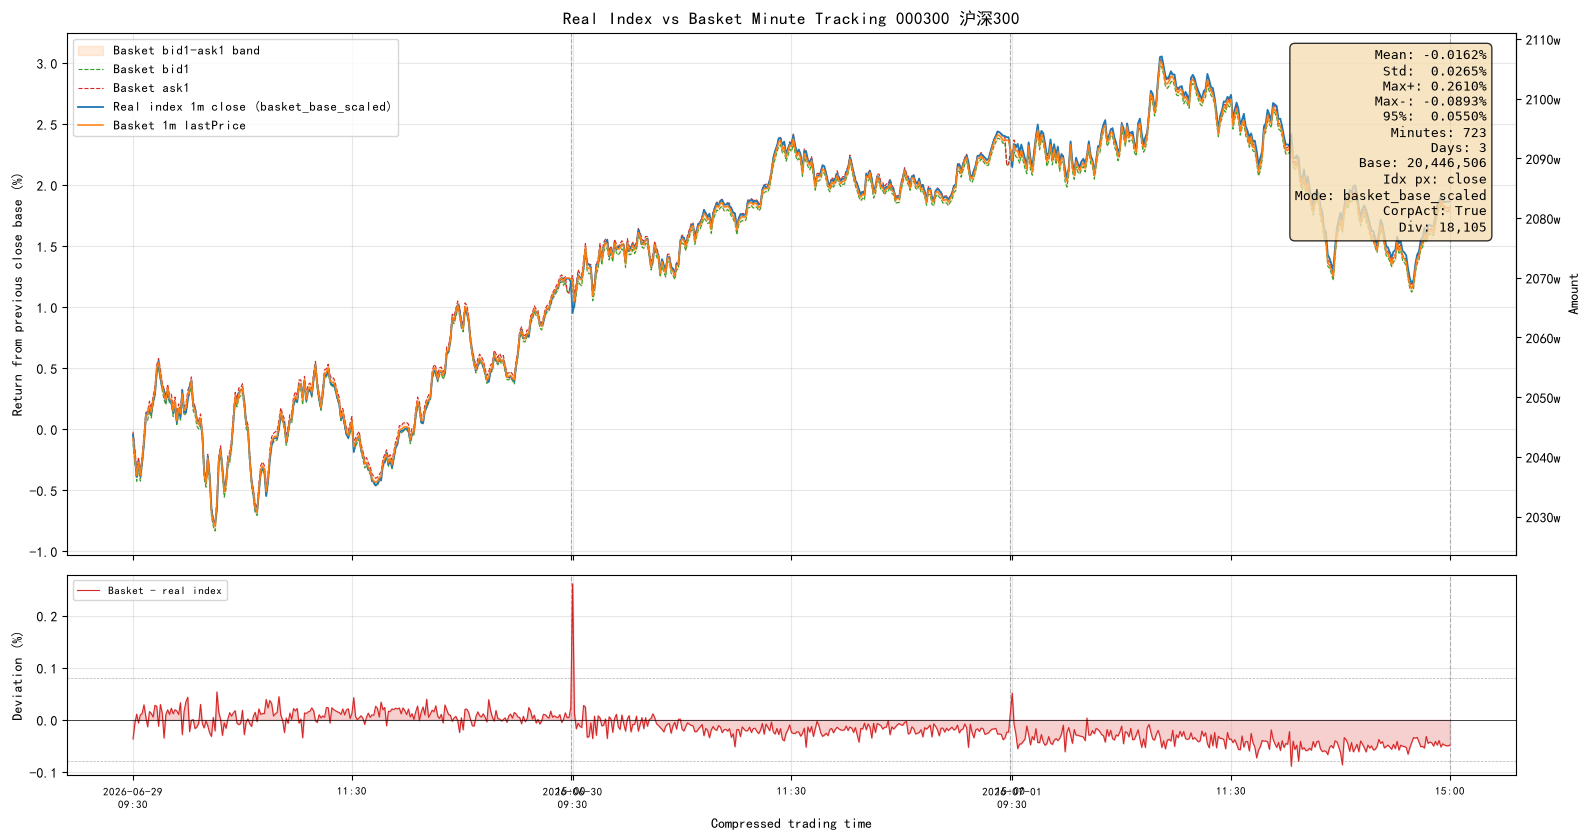

In [29]:
print("Baseline date:", baseline_date_dash)
print("Close weight data date:", closeweight_data_date)
print("Fitting dates:", fitting_date_ls)
print("Rule file:", rule_file_path)
print("Apply corporate actions:", apply_corporate_actions_to_basket)
print("Real index price caliber:", real_index_price_caliber)
print("Real index amount mode:", real_index_amount_mode)
print("[Daily Tracking Stats]")
display(df_daily_tracking_stats[[
    "fitting_date",
    "diff_mean_pct",
    "diff_std_pct",
    "diff_max_positive_pct",
    "diff_max_negative_pct",
    "diff_pct95_pct",
    "n_minutes",
    "daily_dividend_cash",
    "cumulative_dividend_cash",
    "corporate_action_enabled",
    "real_index_base_price",
    "real_index_price_caliber",
    "real_index_amount_mode",
]])
print("[Quantity Adjustments]")
display(df_quantity_adjustments.head(20))
print("[Dividend Records]")
display(df_dividend_records.head(20))
display(outputs["matplotlib_fig"])
display(outputs["plotly_fig"])


Baseline date: 2026-06-18
Close weight data date: 2026-06-18
Fitting dates: ['20260622', '20260624', '20260626', '20260629']
Rule file: security_buy_rules.csv
Apply corporate actions: True
Real index price caliber: close
Real index amount mode: basket_base_scaled
[Daily Tracking Stats]


,fitting_date,diff_mean_pct,diff_std_pct,diff_max_positive_pct,diff_max_negative_pct,diff_pct95_pct,n_minutes,daily_dividend_cash,cumulative_dividend_cash,corporate_action_enabled,real_index_base_price,real_index_price_caliber,real_index_amount_mode
0,20260622,0.008720,0.015731,0.090249,-0.054298,0.033911,241,770.000,770.0000,True,4941.5986,close,basket_base_scaled
1,20260624,0.041177,0.020994,0.144229,-0.030474,0.068437,241,936.600,2069.6500,True,4941.5986,close,basket_base_scaled
2,20260626,0.057746,0.014111,0.097923,-0.003887,0.078017,241,31049.765,34319.7681,True,4941.5986,close,basket_base_scaled
3,20260629,0.075126,0.014969,0.120704,0.029213,0.095937,241,14761.300,49081.0681,True,4941.5986,close,basket_base_scaled


[Quantity Adjustments]


,ex_date,stock_code,before_qty,share_increase_ratio,added_qty,after_qty


[Dividend Records]


,ex_date,stock_code,holding_qty_for_dividend,cash_dividend_per_share,dividend_cash,cumulative_dividend_cash
0,20260622,002736.SZ,2200.0,0.350000,770.0000,770.0000
1,20260623,000768.SZ,1000.0,0.150000,150.0000,920.0000
2,20260623,600584.SH,1100.0,0.100000,110.0000,1030.0000
3,20260623,688041.SH,687.0,0.150000,103.0500,1133.0500
4,20260624,000617.SZ,1800.0,0.047000,84.6000,1217.6500
5,20260624,300498.SZ,3900.0,0.200000,780.0000,1997.6500
6,20260624,600893.SH,1000.0,0.072000,72.0000,2069.6500
7,20260625,600019.SH,6400.0,0.180000,1152.0000,3221.6500
8,20260625,601698.SH,900.0,0.031399,28.2591,3249.9091
9,20260625,688396.SH,394.0,0.051000,20.0940,3270.0031


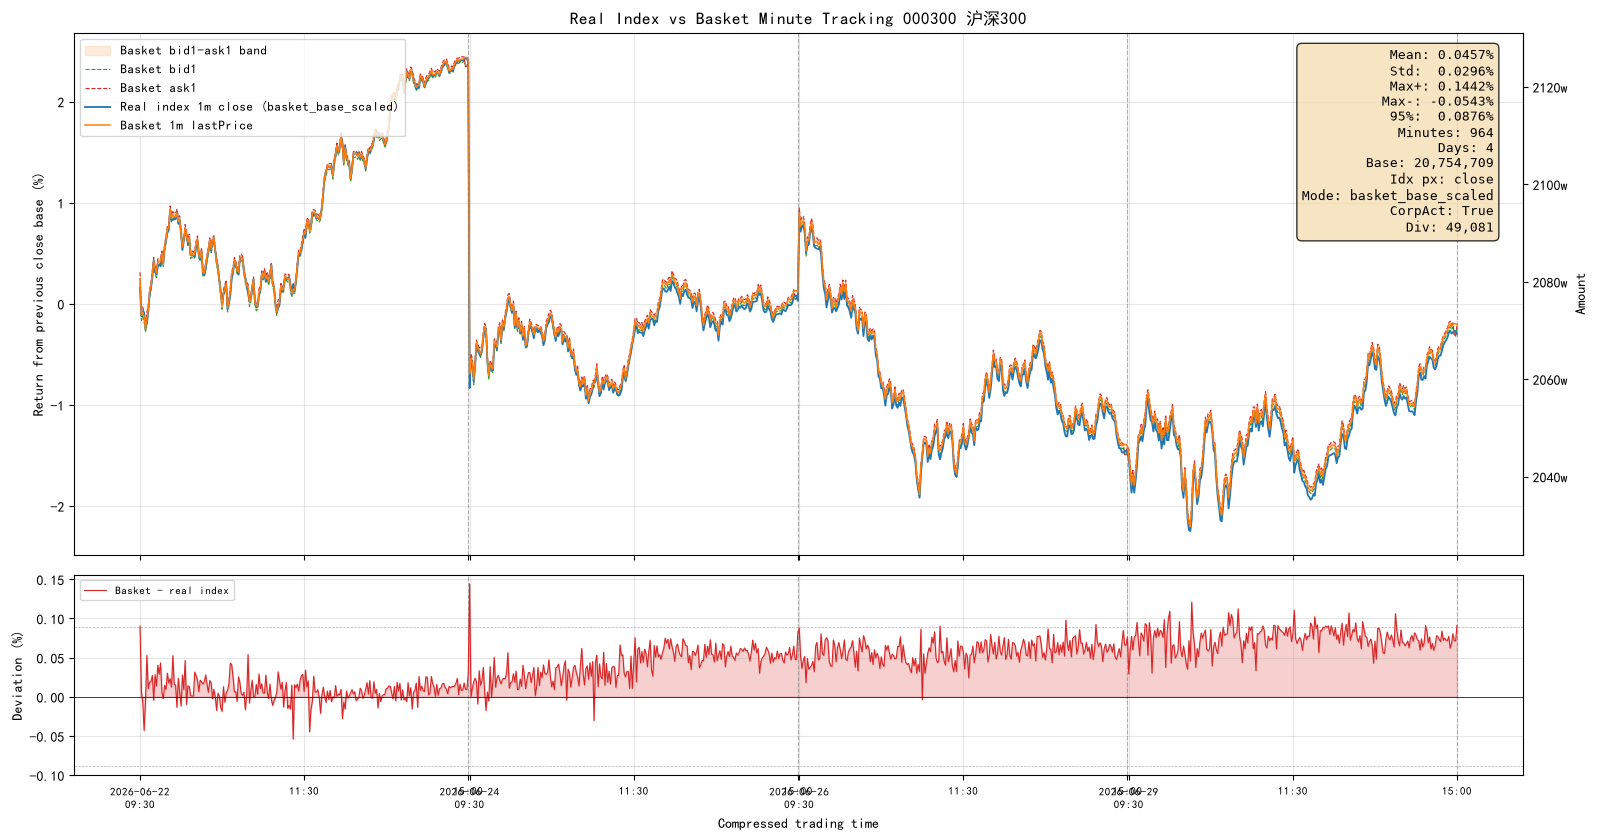

In [80]:
print("Baseline date:", baseline_date_dash)
print("Close weight data date:", closeweight_data_date)
print("Fitting dates:", fitting_date_ls)
print("Rule file:", rule_file_path)
print("Apply corporate actions:", apply_corporate_actions_to_basket)
print("Real index price caliber:", real_index_price_caliber)
print("Real index amount mode:", real_index_amount_mode)
print("[Daily Tracking Stats]")
display(df_daily_tracking_stats[[
    "fitting_date",
    "diff_mean_pct",
    "diff_std_pct",
    "diff_max_positive_pct",
    "diff_max_negative_pct",
    "diff_pct95_pct",
    "n_minutes",
    "daily_dividend_cash",
    "cumulative_dividend_cash",
    "corporate_action_enabled",
    "real_index_base_price",
    "real_index_price_caliber",
    "real_index_amount_mode",
]])
print("[Quantity Adjustments]")
display(df_quantity_adjustments.head(20))
print("[Dividend Records]")
display(df_dividend_records.head(20))
display(outputs["matplotlib_fig"])
display(outputs["plotly_fig"])


Baseline date: 2026-06-15
Close weight data date: 2026-06-15
Fitting dates: ['20260622', '20260624', '20260626', '20260629']
Rule file: security_buy_rules.csv
Apply corporate actions: True
Real index price caliber: close
Real index amount mode: basket_base_scaled
[Daily Tracking Stats]


,fitting_date,diff_mean_pct,diff_std_pct,diff_max_positive_pct,diff_max_negative_pct,diff_pct95_pct,n_minutes,daily_dividend_cash,cumulative_dividend_cash,corporate_action_enabled,real_index_base_price,real_index_price_caliber,real_index_amount_mode
0,20260622,0.081671,0.015790,0.164363,0.018493,0.103147,241,770.000,6415.5180,True,4891.7126,close,basket_base_scaled
1,20260624,0.114224,0.021026,0.217994,0.042529,0.141606,241,936.600,7715.1680,True,4891.7126,close,basket_base_scaled
2,20260626,0.130341,0.014109,0.170581,0.068700,0.150567,241,31049.765,39965.2351,True,4891.7126,close,basket_base_scaled
3,20260629,0.147649,0.015025,0.193028,0.101857,0.168519,241,14781.800,54747.0351,True,4891.7126,close,basket_base_scaled


[Quantity Adjustments]


,ex_date,stock_code,before_qty,share_increase_ratio,added_qty,after_qty
0,20260617,603296.SH,300.0,0.8,240.0,540.0


[Dividend Records]


,ex_date,stock_code,holding_qty_for_dividend,cash_dividend_per_share,dividend_cash,cumulative_dividend_cash
0,20260616,301236.SZ,500.0,0.050146,25.0730,25.0730
1,20260616,302132.SZ,200.0,0.386000,77.2000,102.2730
2,20260616,601077.SH,3900.0,0.117550,458.4450,560.7180
3,20260617,002311.SZ,600.0,1.100000,660.0000,1220.7180
4,20260617,600028.SH,10700.0,0.112000,1198.4000,2419.1180
5,20260617,603296.SH,300.0,2.400000,720.0000,3139.1180
6,20260618,000725.SZ,26900.0,0.056000,1506.4000,4645.5180
7,20260618,600415.SH,2000.0,0.500000,1000.0000,5645.5180
8,20260622,002736.SZ,2200.0,0.350000,770.0000,6415.5180
9,20260623,000768.SZ,1000.0,0.150000,150.0000,6565.5180


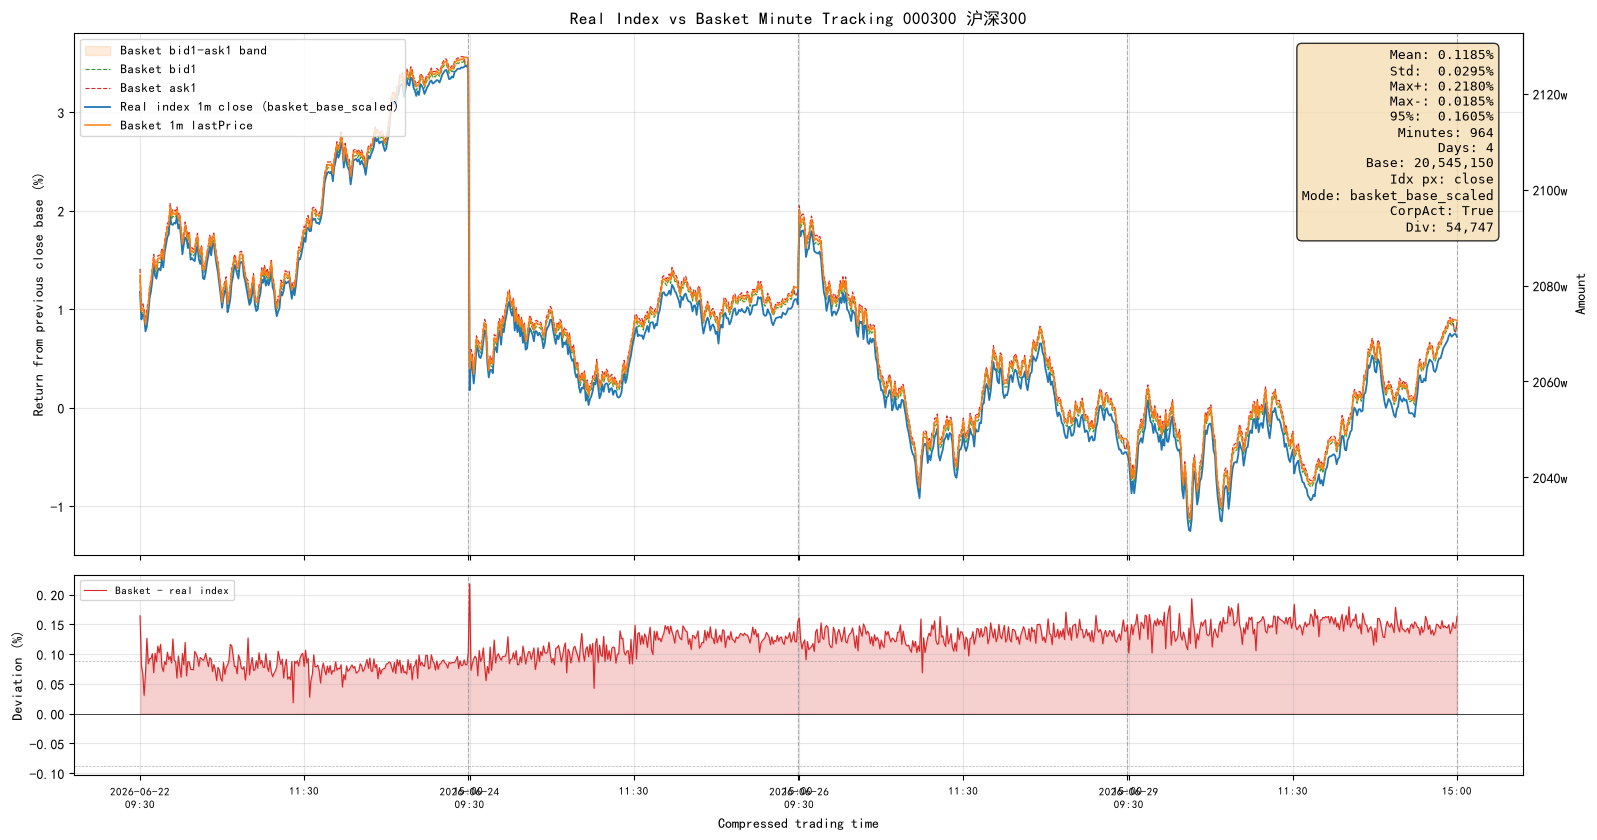

In [ ]:
print("Baseline date:", baseline_date_dash)
print("Close weight data date:", closeweight_data_date)
print("Fitting dates:", fitting_date_ls)
print("Rule file:", rule_file_path)
print("Apply corporate actions:", apply_corporate_actions_to_basket)
print("Real index price caliber:", real_index_price_caliber)
print("Real index amount mode:", real_index_amount_mode)
print("[Daily Tracking Stats]")
display(df_daily_tracking_stats[[
    "fitting_date",
    "diff_mean_pct",
    "diff_std_pct",
    "diff_max_positive_pct",
    "diff_max_negative_pct",
    "diff_pct95_pct",
    "n_minutes",
    "daily_dividend_cash",
    "cumulative_dividend_cash",
    "corporate_action_enabled",
    "real_index_base_price",
    "real_index_price_caliber",
    "real_index_amount_mode",
]])
print("[Quantity Adjustments]")
display(df_quantity_adjustments.head(20))
print("[Dividend Records]")
display(df_dividend_records.head(20))
display(outputs["matplotlib_fig"])
display(outputs["plotly_fig"])
